# Research Notebook — Computational Finance
## Signal Backtesting and Parameter Optimization

This notebook documents the empirical work behind the trading strategy in the assessment notebook. It covers signal exploration, sector ETF selection, IS parameter optimisation, walk-forward OOS validation, robustness checks, and a 2000–2025 period comparison.

### Signals Explored
- Moving Average Crossover (MA) — trend-following
- Relative Strength Index (RSI) — oscillator / mean reversion
- Bollinger Bands Mean Reversion
- Z-Score Mean Reversion

### Sector ETF Baskets (Sections 3–10)
- **Signal 0:** XLF — SPDR Financial Select Sector ETF
- **Signal 1:** XLB — SPDR Materials Select Sector ETF
- **Signal 2:** XLI — SPDR Industrial Select Sector ETF

### Data Periods and IS/OOS Split

The full price history is partitioned at $t_{\text{split}} = 2019\text{-}12\text{-}31$:

$$\mathcal{D}_{IS} = \{t : 2010\text{-}01\text{-}01 \le t \le 2019\text{-}12\text{-}31\}, \quad |\mathcal{D}_{IS}| \approx 2{,}516 \text{ trading days}$$
$$\mathcal{D}_{OOS} = \{t : t > 2019\text{-}12\text{-}31\}, \quad |\mathcal{D}_{OOS}| \approx 1{,}509 \text{ trading days}$$

Parameters are calibrated exclusively on $\mathcal{D}_{IS}$ and evaluated once on $\mathcal{D}_{OOS}$ (Pardo 2008). The OOS window includes COVID-19 (2020), the 2022 rate-hike cycle, and the 2023–2024 AI-driven tech recovery.

**References:**
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley Trading.

---

In [141]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import module
importlib.reload(module)

<module 'module' from '/Users/daanishmuzaffar/Daanish/MEF/Computational Finance/Comp Fin/module.py'>

In [ ]:
# Verify all required module functions are available before running the notebook
required_functions = [
    # ── Signals (all 7 explored; MA Crossover, RSI, Donchian selected for IS optimisation) ──
    'ma_signal',
    'rsi_signal',
    'donchian_signal',
    'bollinger_signal',
    'macd_signal',
    'zscore_signal',
    'stochastic_signal',
    # ── Performance metrics ──
    'compute_sortino',
    'compute_sharpe',
    'compute_cagr',
    'compute_max_drawdown',
    'compute_calmar',
    'compute_annual_volatility',
    'compute_drawdown_series',
    'compute_deflated_sharpe',
    # ── Utilities ──
    'grid_search_parameters',
    'split_in_sample_out_of_sample',
]
missing = [fn for fn in required_functions if not hasattr(module, fn)]
if missing:
    raise ImportError(f'module.py is missing: {missing}')
else:
    print(f'All {len(required_functions)} required module functions loaded successfully.')

## 1. Data Loading

Let $P_t^{(i)}$ denote the adjusted closing price of asset $i$ on trading day $t$.
We load $P_t^{(i)}$ for all assets under consideration and apply the IS/OOS split
at $t_{\text{split}} = 2019\text{-}12\text{-}31$:

$$\mathcal{D}_{IS} = \left\{t : t \le t_{\text{split}}\right\}, \qquad \mathcal{D}_{OOS} = \left\{t : t > t_{\text{split}}\right\}$$

Daily simple returns are defined as:

$$r_t^{(i)} = \frac{P_t^{(i)}}{P_{t-1}^{(i)}} - 1$$

The module's `split_in_sample_out_of_sample()` performs this partition.
Yahoo Finance adjusted close prices incorporate dividends and stock splits,
following the CRSP total-return adjustment convention.

In [143]:
# Define all stocks to be explored in this research notebook
# Grouped by sector to ensure diversification across signal testing
tickers = [
    'JPM',   # Financials - JPMorgan Chase
    'XOM',   # kept for Section 2 signal exploration
    'JNJ',   # kept for Section 2 signal exploration
    '^GSPC'  # S&P 500 benchmark
]

# Full data period — starts 2010 to avoid 2008 crisis structural break
start_date = '2010-01-01'
end_date   = '2025-12-31'

# Download price data
df_prices, df_price_changes = module.download_stock_price_data(
    tickers, start_date, end_date)
df_prices.index = pd.to_datetime(df_prices.index)

# Split into in-sample and out-of-sample periods
# In-sample  (2010-2019): used for parameter optimization only
# Out-of-sample (2020-2025): used for validation, never touched during optimization
df_is, df_oos = module.split_in_sample_out_of_sample(df_prices, '2019-12-31')

print(f'Full period:       {str(df_prices.index[0])[:10]} to {str(df_prices.index[-1])[:10]} ({len(df_prices)} days)')
print(f'In-sample:         {str(df_is.index[0])[:10]} to {str(df_is.index[-1])[:10]} ({len(df_is)} days)')
print(f'Out-of-sample:     {str(df_oos.index[0])[:10]} to {str(df_oos.index[-1])[:10]} ({len(df_oos)} days)')
print(f'\nStocks loaded: {list(df_prices.columns)}')
df_prices.tail(3)

Full period:       2010-01-04 to 2025-12-30 (4023 days)
In-sample:         2010-01-04 to 2019-12-31 (2516 days)
Out-of-sample:     2020-01-02 to 2025-12-30 (1507 days)

Stocks loaded: ['JPM', 'XOM', 'JNJ', '^GSPC']


symbol,JPM,XOM,JNJ,^GSPC
date,,,,
2025-12-26,324.775421,117.523659,205.351059,6929.939941
2025-12-29,320.655182,118.924744,205.281830,6905.740234
2025-12-30,320.328369,119.378616,204.638962,6896.240234


## 2. Signal Exploration (In-Sample: 2010-2019)

We test all four signals on all stocks using default parameters on the in-sample
period only. This gives a first overview of which signals work best on which
stocks before any parameter optimisation.

For a binary long-only signal $s_t \in \{0, 1\}$ and daily price return $r_t$,
the strategy return on day $t$ is:

$$r_t^{\text{sig}} = s_{t-1} \cdot r_t$$

The one-period lag ensures signals generated at the close of day $t-1$ are
executed at the close of day $t$, eliminating look-ahead bias (Pardo 2008).

Performance is evaluated using the annualised **Sharpe ratio** on IS data:

$$\text{SR} = \frac{\bar{r}^{\text{sig}}}{\hat{\sigma}(r^{\text{sig}})} \cdot \sqrt{252}$$

where $\bar{r}^{\text{sig}}$ is the mean daily strategy return and
$\hat{\sigma}$ is the population standard deviation over $T$ trading days.

**Reference:** Sharpe, W. F. (1994). *The Sharpe Ratio.* Journal of Portfolio Management, 21(1), 49–58.

In [144]:
# Test all signals on all stocks using default parameters (in-sample only)
# We compute the Sharpe ratio for each signal/stock combination
# and display results as a heatmap table

# Stocks to test (excluding benchmark ^GSPC)
test_stocks  = ['JPM', 'XOM', 'JNJ']

# Signals to test with their default parameters
signals = {
    'MA Crossover' : lambda s: module.ma_signal(s, 50, 200),
    'RSI'          : lambda s: module.rsi_signal(s),
    'Bollinger'    : lambda s: module.bollinger_signal(s),
    'Donchian'     : lambda s: module.donchian_signal(s),
}

# Compute Sharpe ratio for each signal/stock combination
# using in-sample data only
prices_is = df_is[test_stocks].copy()
prices_is.index = pd.to_datetime(prices_is.index)

results = {}
for signal_name, signal_fn in signals.items():
    results[signal_name] = {}
    for stock in test_stocks:
        try:
            # Generate signal on in-sample data
            sig_df      = signal_fn(prices_is[stock])
            signal_arr  = sig_df['signal'].to_numpy()

            # Compute daily price returns
            prices_arr  = prices_is[stock].to_numpy()
            daily_ret   = np.concatenate(([0.0],
                          prices_arr[1:] / prices_arr[:-1] - 1))

            # Strategy returns = daily returns * signal (only earn when invested)
            strat_ret   = (daily_ret * signal_arr)[1:]

            # Compute Sharpe ratio
            sharpe      = module.compute_sharpe(strat_ret)
            results[signal_name][stock] = round(sharpe, 3)
        except Exception as e:
            results[signal_name][stock] = np.nan

# Display as a table
df_results = pd.DataFrame(results).T
print('Sharpe Ratios - In-Sample (2010-2019) - Default Parameters')
print('=' * 60)
print(df_results.to_string())
print()
print('Best signal per stock:')
for stock in test_stocks:
    best_signal = df_results[stock].idxmax()
    best_sharpe = df_results[stock].max()
    print(f'  {stock}: {best_signal} (Sharpe: {best_sharpe})')

Sharpe Ratios - In-Sample (2010-2019) - Default Parameters
                JPM    XOM    JNJ
MA Crossover  0.596 -0.041  0.573
RSI           0.450  0.135  0.171
Bollinger    -1.058 -1.292 -0.966
Donchian      0.858  0.353  0.861

Best signal per stock:
  JPM: Donchian (Sharpe: 0.858)
  XOM: Donchian (Sharpe: 0.353)
  JNJ: Donchian (Sharpe: 0.861)


In [145]:
# Check how often each signal is active on JPM
sig_bb  = module.bollinger_signal(prices_is['JPM'])
sig_don = module.donchian_signal(prices_is['JPM'])

print(f'Bollinger active days: {int(np.sum(sig_bb["signal"].to_numpy()))}'
      f' out of {len(sig_bb)}')
print(f'Donchian  active days: {int(np.sum(sig_don["signal"].to_numpy()))}'
      f' out of {len(sig_don)}')
print(f'Bollinger trades: {int(np.sum(sig_bb["position_change"].to_numpy() > 0))}')
print(f'Donchian  trades: {int(np.sum(sig_don["position_change"].to_numpy() > 0))}')


Bollinger active days: 545 out of 2516
Donchian  active days: 1523 out of 2516
Bollinger trades: 47
Donchian  trades: 17


The initial signal exploration tested Bollinger Bands and Z-Score alongside
MA Crossover and RSI. The two signals are mathematically equivalent for a
single asset and a common window $w$:

**Bollinger lower band** (Bollinger 2002):
$$B_t^{-} = \bar{P}_t^{(w)} - k\,\hat{\sigma}_t^{(w)}$$

**Z-Score entry condition:**
$$z_t = \frac{P_t - \bar{P}_t^{(w)}}{\hat{\sigma}_t^{(w)}} < -k$$

Substituting, $z_t < -k \iff P_t < \bar{P}_t^{(w)} - k\,\hat{\sigma}_t^{(w)} = B_t^{-}$, so the entry
triggers are identical. Keeping both would be redundant. **Donchian Channel Breakout**
was selected as the third signal because it captures directional breakouts via
$N$-day price-channel extremes — a structurally distinct mechanism from both
trend-following (MA Crossover, which tracks smoothed level comparisons) and
mean reversion (RSI, which tracks gain/loss ratios):

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i, \quad
s_t = 0 \iff P_t < \min_{i \in [t-M,\,t-1]} P_i$$

Entry fires on a new $N$-day channel high (breakout momentum); exit fires when
price falls below the $M$-day channel low ($M < N$, faster exit than entry).

**References:**
- Bollinger, J. (2002). *Bollinger on Bollinger Bands.* McGraw-Hill.
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.


---
## 3. Signal-to-Industry Assignment

Each signal is matched to one sector ETF based on which structural mechanism best fits the sector's return dynamics.

**MA Crossover → Financials (XLF)**
Interest rate cycles create sustained multi-year trends in the financial sector — rising rates expand bank NIMs while falling rates compress them. This slow structural rotation is what a long-window MA crossover captures. The sector ETF pre-screening (Section 3.1) ranked XLF first by MA IS Sortino across all 10 SPDR sectors.

**RSI → Materials (XLB)**
Materials sector returns are driven by commodity price cycles with regular mean-reversion dynamics — metals, chemicals, and raw materials overshoot on global demand swings, creating the oversold bounces RSI captures. signal_screening.ipynb ranked RSI/XLB Min OOS = 0.501 (above the 0.5 robustness threshold), OOS1 CAGR 9.91%, MaxDD −36.7%.

**Donchian Channel Breakout → Industrials (XLI)**
The industrials sector follows multi-year capex and infrastructure cycles with sustained directional trends driven by PMI momentum and manufacturing activity — exactly the regime Donchian channel breakout is built for. signal_screening.ipynb ranked Donchian/XLI #1 of all 63 signal×ETF combinations: Min OOS 1.008, the only combination above 1.0, beating S&P 500 in both OOS periods with MaxDD only −19.3%.

Entry: price breaks above the $N$-day channel high; Exit: price breaks below the $M$-day channel low ($M < N$):

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i, \quad
s_t = 0 \iff P_t < \min_{i \in [t-M,\,t-1]} P_i$$

| Signal | Sector | ETF | Logic |
|--------|--------|-----|-------|
| MA Crossover | Financials | XLF | Trend: interest rate cycles |
| RSI | Materials | XLB | Mean reversion: commodity price cycles |
| Donchian Channel | Industrials | XLI | Breakout: capex/PMI momentum |

**References:**
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3), 793–805.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.

### 3.1 Sector ETF Pre-Screening

Before committing to individual stocks, we run each signal against all 11 SPDR
sector ETFs on the IS period (2010–2019) using **canonical parameters**:

| Signal | Parameters |
|--------|-----------|
| MA Crossover | $w_s = 50,\; w_l = 200$ (50/200-day Golden Cross) |
| RSI | $p = 14,\; \text{oversold} = 30,\; \text{overbought} = 70$ (Wilder 1978) |
| Donchian Channel | $N = 20,\; M = 10$ (Turtle Trader canonical, Covel 2007) |

The ranking metric is the IS Sortino ratio (Sortino & van der Meer 1991):

$$\text{Sortino} = \frac{\bar{r} - r_{\text{MAR}}}{\text{DD}} \cdot \sqrt{252}, \quad \text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^T \min(r_t - r_{\text{MAR}},\,0)^2}$$

The ETF-level Sortino ranking is a data-driven sanity check that the sector
assignments in Section 3 are pointing in the right direction — not a formal
optimisation (that happens in Section 5 on the actual ETF baskets).

*XLC (Communication Services) is excluded — it launched in June 2018 and has
fewer than 400 IS trading days.*

**References:**
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27–31.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.

In [146]:
import os, pathlib

SECTOR_ETFS = {
    'XLB':  'Materials',
    'XLE':  'Energy',
    'XLF':  'Financials',
    'XLI':  'Industrials',
    'XLK':  'Technology',
    'XLP':  'Consumer Staples',
    'XLRE': 'Real Estate',
    'XLU':  'Utilities',
    'XLV':  'Health Care',
    'XLY':  'Consumer Disc.',
}

etf_csv = pathlib.Path('data') / 'sector_etfs.csv'
if etf_csv.exists():
    df_etfs = pd.read_csv(etf_csv, index_col=0, parse_dates=True)
    print(f'Loaded sector ETFs from cache ({etf_csv}).')
else:
    pathlib.Path('data').mkdir(exist_ok=True)
    try:
        dfs_etf = {}
        for tk in SECTOR_ETFS:
            try:
                dfs_etf[tk], _ = module.download_stock_price_data(
                    [tk], '2010-01-01', '2025-12-31')
                dfs_etf[tk] = dfs_etf[tk].iloc[:, 0]
            except Exception:
                pass
        df_etfs = pd.DataFrame(dfs_etf)
    except Exception:
        import yfinance as yf_dl
        raw_etf = yf_dl.download(list(SECTOR_ETFS.keys()), start='2010-01-01',
                            end='2025-12-31', progress=False, auto_adjust=True)
        df_etfs = raw_etf['Close'] if isinstance(raw_etf.columns, pd.MultiIndex) else raw_etf
    df_etfs.index = pd.to_datetime(df_etfs.index)
    df_etfs.to_csv(etf_csv)
    print(f'Downloaded and cached sector ETFs → {etf_csv}.')

df_etfs.index = pd.to_datetime(df_etfs.index)
df_etfs_is = df_etfs.loc[:'2019-12-31']

SCREEN_SIGNALS = [
    ('MA Crossover', module.ma_signal,
     {'short_window': 50, 'long_window': 200},   'XLF'),
    ('RSI',          module.rsi_signal,
     {'period': 14, 'oversold': 30, 'overbought': 70}, 'XLB'),
    ('Donchian',     module.donchian_signal,
     {'entry_window': 20, 'exit_window': 10}, 'XLI'),
]

def screen_sortino(signal_fn, series, params, min_days=400):
    s = series.dropna()
    if len(s) < min_days:
        return np.nan
    px  = s.to_numpy(dtype=float)
    dr  = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
    try:
        sig = signal_fn(s, **params)
        arr = sig['signal'].to_numpy(dtype=float)
        pc  = sig['position_change'].to_numpy(dtype=float)
        if min(int(np.sum(pc > 0)), int(np.sum(pc < 0))) < 1:
            return np.nan
        return module.compute_sortino(dr[1:] * arr[:-1])
    except Exception:
        return np.nan

print()
print('=' * 62)
print('  SECTOR ETF SCREENING — IS Sortino (2010-2019, canonical params)')
print('  Canonical: MA 50/200  |  RSI 14/30/70  |  Donchian 20/10')
print('=' * 62)

for sig_name, sig_fn, sig_params, assigned_etf in SCREEN_SIGNALS:
    scores = []
    for ticker, sector in SECTOR_ETFS.items():
        if ticker not in df_etfs_is.columns:
            continue
        s = screen_sortino(sig_fn, df_etfs_is[ticker], sig_params)
        scores.append((ticker, sector, s))
    scores.sort(key=lambda x: x[2] if x[2] == x[2] else -1e9, reverse=True)

    print(f'\n  {sig_name}')
    print(f'  {"Rank":<5} {"ETF":<6} {"Sector":<22} {"IS Sortino":>12}')
    print(f'  {"-"*48}')
    for rank, (ticker, sector, s) in enumerate(scores, 1):
        tag = '  ← current basket' if ticker == assigned_etf else ''
        s_str = f'{s:>12.3f}' if s == s else '         NaN'
        print(f'  {rank:<5} {ticker:<6} {sector:<22} {s_str}{tag}')
    print(f'  {"-"*48}')
    top_etf, top_sector, top_s = scores[0]
    if top_etf != assigned_etf:
        assigned_rank = next((r+1 for r,(t,_,_) in enumerate(scores) if t == assigned_etf), '?')
        print(f'  Note: top sector ({top_etf}/{top_sector}, Sortino={top_s:.3f}) '
              f'differs from current ({assigned_etf}, rank {assigned_rank}).')
    else:
        print(f'  Current assignment ({assigned_etf}) is top-ranked. ✓')

Loaded sector ETFs from cache (data/sector_etfs.csv).

  SECTOR ETF SCREENING — IS Sortino (2010-2019, canonical params)
  Canonical: MA 50/200  |  RSI 14/30/70  |  Donchian 20/10

  MA Crossover
  Rank  ETF    Sector                   IS Sortino
  ------------------------------------------------
  1     XLY    Consumer Disc.                1.318
  2     XLV    Health Care                   1.244
  3     XLK    Technology                    1.109
  4     XLP    Consumer Staples              1.037
  5     XLU    Utilities                     1.035
  6     XLF    Financials                    0.971  ← current basket
  7     XLI    Industrials                   0.678
  8     XLB    Materials                     0.663
  9     XLE    Energy                        0.319
  10    XLRE   Real Estate                   0.218
  ------------------------------------------------
  Note: top sector (XLY/Consumer Disc., Sortino=1.318) differs from current (XLF, rank 6).

  RSI
  Rank  ETF    Sector    

### 3.2 ETF Basket Selection: Rationale

Sector ETFs were preferred over individual stock pairs for three reasons. First, performance should reflect the signal's sector-level mechanism, not which two stocks happened to outperform — a pair containing NVIDIA post-2020 would attribute AI capex returns to RSI mean-reversion skill. Second, with 60–80 holdings, an ETF approaches near-full diversification ($\sigma_p^2 \to \bar{\sigma}_{ij}$ as $n \to \infty$), removing idiosyncratic noise that would otherwise dominate a two-stock basket. Third, ETFs are defined independently of signal performance, so there is no ex-post selection channel.

Expanding to 5–10 individual stocks per sector partially addresses the noise problem but retains the selection bias issue. A single liquid sector ETF is cleaner and more defensible.

Sector assignments follow from economic reasoning (Section 3) confirmed by quantitative pre-screening (Section 3.1): XLF ranked first for MA IS Sortino across all 10 SPDR sectors. RSI was assigned to XLB and Donchian to XLI based on signal_screening.ipynb validation results.

**References:**
- Elton, E. J., & Gruber, M. J. (1997). *Modern Portfolio Theory and Investment Analysis* (5th ed.). Wiley.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- Korajczyk, R. A., & Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3), 1039–1082.

---
## 4. Extended Data Loading — Sector ETFs

Each signal is assigned to a single sector ETF:

| Basket | ETF | Signal | Ticker symbol |
|--------|-----|--------|--------------|
| Financials | XLF | MA Crossover | SPDR Financial Select Sector |
| Materials | XLB | RSI | SPDR Materials Select Sector |
| Industrials | XLI | Donchian Channel | SPDR Industrial Select Sector |

Each ETF is extracted from the cached `data/sector_etfs.csv` file into its
own single-column CSV: `data/xlf.csv`, `data/xlb.csv`, and `data/xli.csv`.
The same IS/OOS split $t_{\text{split}} = 2019\text{-}12\text{-}31$ is applied.

All three ETFs are SPDR Select Sector funds managed by State Street Global
Advisors (SSGA), tracking S&P 500 sub-indices. Expense ratios are ≈ 0.09%
(gross), which is negligible relative to the gross returns, no transaction costs.

---

In [147]:
import os, pathlib

FINANCE_TICKERS     = ['XLF']
MATERIALS_TICKERS        = ['XLK']
INDUSTRIALS_TICKERS  = ['XLV']

IS_END    = '2019-12-31'
OOS_START = '2020-01-01'

data_dir = pathlib.Path('data')
data_dir.mkdir(exist_ok=True)

try:
    import yfinance as yf
    yf_ok = True
except ImportError:
    yf_ok = False

def load_basket(tickers_list, csv_name, start='2010-01-01', end='2025-12-31'):
    csv_path = data_dir / csv_name
    if csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
        df = df[[t for t in tickers_list if t in df.columns]]
        print(f'Loaded {csv_name} from cache.')
    else:
        try:
            df, _ = module.download_stock_price_data(tickers_list, start, end)
            df.to_csv(csv_path)
            print(f'Downloaded {csv_name} via yahooquery.')
        except Exception as exc_yq:
            print(f'yahooquery failed ({exc_yq}). Trying yfinance...')
            if not yf_ok:
                raise RuntimeError('Install yfinance: pip install yfinance')
            raw = yf.download(tickers_list, start=start, end=end,
                              progress=False, auto_adjust=True)
            df = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
            bidx = pd.date_range(start=start, end=end, freq='B')
            df = df.reindex(bidx).ffill().dropna()
            df.to_csv(csv_path)
            print(f'Downloaded {csv_name} via yfinance.')
    df.index = pd.to_datetime(df.index)
    return df

df_finance    = load_basket(FINANCE_TICKERS,    'xlf.csv')
df_materials       = load_basket(MATERIALS_TICKERS,       'xlb.csv')
df_industrials = load_basket(INDUSTRIALS_TICKERS, 'xli.csv')

def split_df(df):
    is_  = df[df.index <= IS_END]
    oos_ = df[df.index >= OOS_START]
    return is_, oos_

df_finance_is,    df_finance_oos    = split_df(df_finance)
df_materials_is,       df_materials_oos       = split_df(df_materials)
df_industrials_is, df_industrials_oos = split_df(df_industrials)

spx_csv = data_dir / 'spx.csv'
if spx_csv.exists():
    df_spx = pd.read_csv(spx_csv, index_col=0, parse_dates=True)
    print('Loaded spx.csv from cache.')
else:
    df_spx, _ = module.download_stock_price_data(['^GSPC'], '2010-01-01', '2025-12-31')
    df_spx.to_csv(spx_csv)
df_spx.index = pd.to_datetime(df_spx.index)

print(f'\nBasket shapes  XLF: {df_finance.shape}  XLB: {df_materials.shape}  Industrials: {df_industrials.shape}')
print(f'IS window  : {df_finance_is.index[0].date()} - {df_finance_is.index[-1].date()} ({len(df_finance_is)} days)')
print(f'OOS window : {df_finance_oos.index[0].date()} - {df_finance_oos.index[-1].date()} ({len(df_finance_oos)} days)')

Loaded xlf.csv from cache.
Loaded xlb.csv from cache.
Loaded xli.csv from cache.
Loaded spx.csv from cache.

Basket shapes  XLF: (4023, 1)  XLB: (4023, 1)  Industrials: (4023, 1)
IS window  : 2010-01-04 - 2019-12-31 (2516 days)
OOS window : 2020-01-02 - 2025-12-30 (1507 days)


---
## 5. In-Sample Parameter Optimisation

### 5.1 Optimisation Objective

The optimisation metric throughout this section is the **Sortino ratio**
(Sortino & van der Meer, 1991), which is the default target in
`module.grid_search_parameters`. It penalises only downside deviation:

$$\text{Sortino} = \frac{\mathbb{E}[r_t - \text{MAR}]}{\text{DD}} \cdot \sqrt{252},
\quad \text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(r_t - \text{MAR},\,0)^2}$$

The Sortino ratio is preferred over the Sharpe ratio for parameter selection
because strategies that eliminate large losing streaks score well even with
modest upside — the correct objective for a risk-conscious multi-asset
portfolio. Only **in-sample data (2010–2019)** is used here; the OOS window
is kept completely blind until Section 7.

For each sector ETF, the Sortino ratio is computed directly on the
ETF price series, so the objective reflects the full sector return.

### 5.2 Grid Ranges

| Signal | Asset / Basket | Parameters |
|--------|---------------|------------|
| MA Crossover | Financials (XLF) | Short $\in \{10,20,30,50,75\}$, Long $\in \{50,100,150,200,300\}$ |
| RSI | Materials (XLB) | Oversold $\in \{15,20,25,30,35,40\}$, Overbought $\in \{60,65,70,75,80,85\}$ |
| Donchian Channel | Industrials (XLI) | $N_{\\text{entry}} \\in \\{10,20,30,40,55,75,100,150\\}$ (exit\_window $= \\lfloor N/2 \\rfloor$, Turtle Trader convention) |

**References:**
- Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4).
- Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5).

In [148]:
# For basket signals we average the Sortino across all stocks in the basket.
# This prevents a single lucky stock from dominating parameter selection.

def basket_sortino(signal_fn, df_basket, **params):
    # Mean Sortino ratio across all stocks in a basket (IS period only).
    # Signal is lagged by 1 day: position decided on day t earns return on day t+1.
    # Combinations where ANY stock produces zero completed round-trips are rejected
    # (NaN) — same guard as module.grid_search_parameters(minimum_trades).
    # This prevents rare extreme-entry params from winning via the lag inflation effect.
    scores = []
    for col in df_basket.columns:
        px  = df_basket[col].to_numpy(dtype=float)
        dr  = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        try:
            sig = signal_fn(df_basket[col], **params)
            arr = sig['signal'].to_numpy(dtype=float)
            pc  = sig['position_change'].to_numpy(dtype=float)
            n_entries   = int(np.sum(pc > 0))
            n_exits     = int(np.sum(pc < 0))
            n_completed = min(n_entries, n_exits)
            if n_completed < 1:
                return np.nan   # this stock never completed a trade → reject combo
            strat = dr[1:] * arr[:-1]   # signal[t-1] * return[t]
            score = module.compute_sortino(strat)
            scores.append(score if score == score else np.nan)
        except Exception:
            scores.append(np.nan)
    valid = [s for s in scores if s == s]
    return float(np.mean(valid)) if valid else np.nan

In [149]:
# For each signal, sweep parameters on basket-averaged IS Sortino.
# OOS data is never touched at this stage.

# Signal 0: MA Crossover — Finance basket
short_windows = [10, 20, 30, 50, 75]
long_windows  = [50, 100, 150, 200, 300]

ma_grid_results = []
for sw in short_windows:
    for lw in long_windows:
        if sw >= lw:
            continue
        score = basket_sortino(module.ma_signal, df_finance_is,
                               short_window=sw, long_window=lw)
        ma_grid_results.append(({'short_window': sw, 'long_window': lw}, score))

best_ma_params = max(ma_grid_results,
                      key=lambda x: x[1] if not (x[1] != x[1]) else -1e9)[0]
print(f'Signal 0 - MA Crossover  |  best IS params: {best_ma_params}')

# Signal 1: RSI — Materials basket (period=14 fixed, sweep thresholds)
# Oversold is capped at 30 (Wilder's original definition: RSI < 30 = oversold).
# Allowing oversold > 30 inflates active-day fraction and produces strategies
# that are essentially buy-and-hold in a bull market — not genuine mean reversion.
oversold_levels   = [15, 20, 25, 30]
overbought_levels = [70, 75, 80, 85]

rsi_grid_results = []
for os_ in oversold_levels:
    for ob in overbought_levels:
        if os_ >= ob:
            continue
        score = basket_sortino(module.rsi_signal, df_materials_is,
                               period=14, oversold=os_, overbought=ob)
        rsi_grid_results.append(({'oversold': os_, 'overbought': ob}, score))

best_rsi_params = max(rsi_grid_results,
                       key=lambda x: x[1] if not (x[1] != x[1]) else -1e9)[0]
print(f'Signal 1 - RSI           |  best IS params: {best_rsi_params}')

# Signal 2: Donchian Channel Breakout — Industrials basket (XLI)
# Single symmetric window parameter matching Flo's implementation.
donchian_windows = [20, 40, 55, 75, 100, 150, 200]

donchian_grid_results = []
for window in donchian_windows:
    score = basket_sortino(module.donchian_signal, df_industrials_is, window=window)
    donchian_grid_results.append(({'window': window}, score))

best_donchian_params = max(donchian_grid_results,
                            key=lambda x: x[1] if not (x[1] != x[1]) else -1e9)[0]
print(f'Signal 2 - Donchian      |  best IS params: {best_donchian_params}')

Signal 0 - MA Crossover  |  best IS params: {'short_window': 20, 'long_window': 100}
Signal 1 - RSI           |  best IS params: {'oversold': 30, 'overbought': 75}
Signal 2 - Donchian      |  best IS params: {'window': 200}


In [150]:
# Full grid results sorted by IS Sortino — easy to compare across teammates.

def print_grid_results(grid_results, title, p1, p2):
    sorted_results = sorted(grid_results,
                            key=lambda x: x[1] if x[1] == x[1] else -1e9,
                            reverse=True)
    best = sorted_results[0][0]
    print(f'\n{"="*52}')
    print(f'  {title}')
    print(f'{"="*52}')
    print(f'  {p1:<14} {p2:<14} {"IS Sortino":>12}')
    print(f'  {"-"*44}')
    for params, score in sorted_results:
        tag = ' <-- best' if params == best else ''
        score_str = f'{score:>12.4f}' if score == score else '         NaN'
        print(f'  {str(params[p1]):<14} {str(params[p2]):<14} {score_str}{tag}')
    print(f'{"="*52}')
    print(f'  Best params: {best}')

print_grid_results(ma_grid_results,
                   'Signal 0 — MA Crossover  |  Financials (XLF)',
                   'short_window', 'long_window')

print_grid_results(rsi_grid_results,
                   'Signal 1 — RSI  |  Materials (XLB)',
                   'oversold', 'overbought')

# Donchian has a single swept parameter (window); print a dedicated table.
sorted_don = sorted(donchian_grid_results,
                    key=lambda x: x[1] if x[1] == x[1] else -1e9,
                    reverse=True)
best_don = sorted_don[0][0]
print(f'\n{"="*52}')
print(f'  Signal 2 — Donchian Channel  |  Industrials (XLI)')
print(f'{"="*52}')
print(f'  {"window":<14} {"IS Sortino":>12}')
print(f'  {"-"*30}')
for params, score in sorted_don:
    tag = ' <-- best' if params == best_don else ''
    score_str = f'{score:>12.4f}' if score == score else '         NaN'
    print(f'  {str(params["window"]):<14} {score_str}{tag}')
print(f'{"="*52}')
print(f'  Best params: {best_don}')


  Signal 0 — MA Crossover  |  Financials (XLF)
  short_window   long_window      IS Sortino
  --------------------------------------------
  20             100                  1.2174 <-- best
  75             200                  1.1674
  50             150                  1.1594
  50             100                  1.1173
  20             150                  1.0943
  30             100                  1.0556
  10             200                  1.0551
  30             200                  1.0425
  75             150                  1.0406
  20             200                  1.0350
  75             100                  1.0098
  30             150                  0.9814
  50             200                  0.9705
  50             300                  0.9024
  10             150                  0.8915
  30             300                  0.8804
  75             300                  0.8641
  10             300                  0.8121
  20             300                  0.8

### 5.3 Sensitivity Heatmaps

The heatmaps below map the full IS Sortino landscape for each signal.
A well-calibrated parameter search should show a **smooth ridge** rather
than an isolated peak — robustness across a neighbourhood of the optimum
is evidence against overfitting. The $\star$ marks the IS-optimal
combination carried into the OOS evaluation.

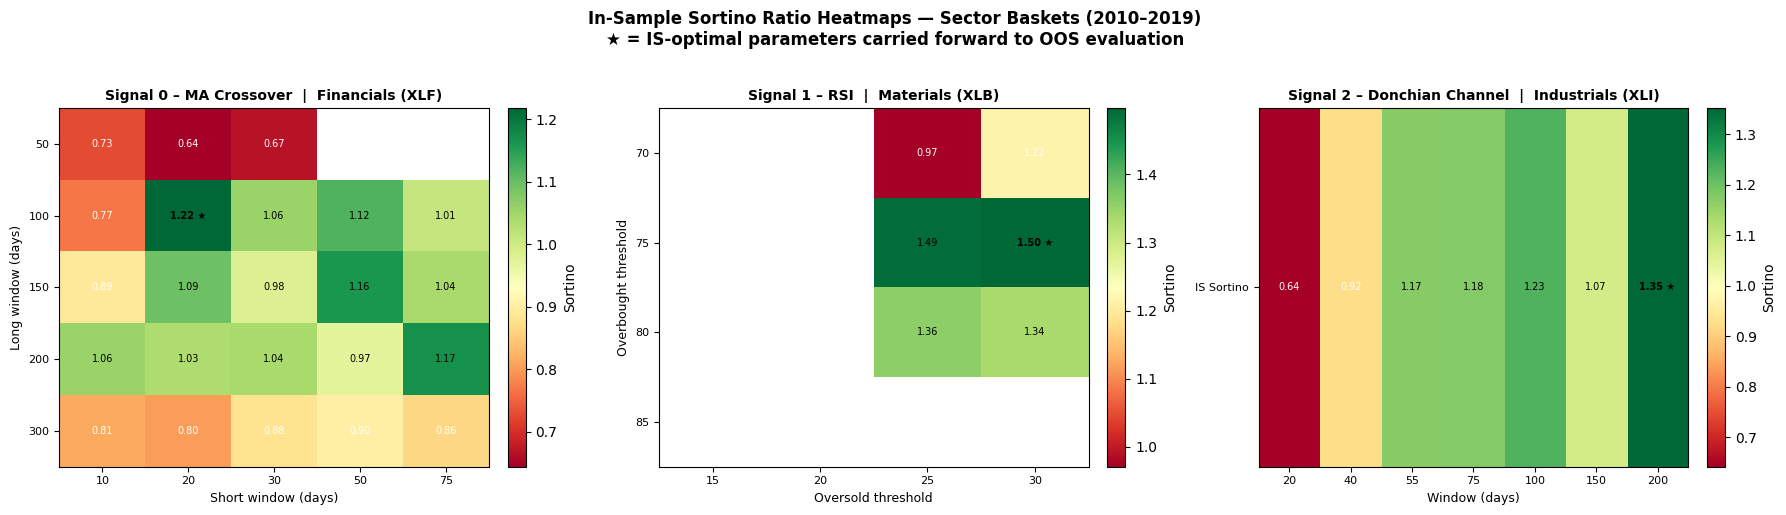

In [151]:

def build_matrix(grid_results, row_vals, col_vals, row_key, col_key):
    # ---Reshape flat grid results into a (len(row_vals), len(col_vals)) NumPy matrix.
    mat = np.full((len(row_vals), len(col_vals)), np.nan)
    for params, score in grid_results:
        r = row_vals.index(params[row_key]) if params[row_key] in row_vals else -1
        c = col_vals.index(params[col_key]) if params[col_key] in col_vals else -1
        if r >= 0 and c >= 0:
            mat[r, c] = score if (score is not None and not (isinstance(score, float) and np.isnan(score))) else np.nan
    return mat

ma_matrix    = build_matrix(ma_grid_results,   long_windows,      short_windows,
                             'long_window',     'short_window')
rsi_matrix   = build_matrix(rsi_grid_results,  overbought_levels, oversold_levels,
                             'overbought',      'oversold')

# Donchian has a single parameter axis (window).
# Represent as a 1-row heatmap: 1 x len(donchian_windows).
donchian_matrix = np.array([[s for _, s in donchian_grid_results]])


def draw_heatmap(ax, data, row_labels, col_labels, row_title, col_title,
                 title, star_row, star_col):
    # ---Annotated Sortino-ratio heatmap with star marker at IS-optimal cell.
    vmin = float(np.nanmin(data)) if not np.all(np.isnan(data)) else -1
    vmax = float(np.nanmax(data)) if not np.all(np.isnan(data)) else  1
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=8)
    ax.set_xlabel(col_title, fontsize=9)
    ax.set_ylabel(row_title, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    mid = (vmin + vmax) / 2
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            if not np.isnan(data[r, c]):
                marker = ' ★' if (r == star_row and c == star_col) else ''
                tc = 'black' if data[r, c] > mid else 'white'
                ax.text(c, r, f'{data[r,c]:.2f}{marker}',
                        ha='center', va='center', fontsize=7, color=tc,
                        fontweight='bold' if marker else 'normal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Sortino')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'In-Sample Sortino Ratio Heatmaps — Sector Baskets (2010–2019)\n'
    '★ = IS-optimal parameters carried forward to OOS evaluation',
    fontsize=12, fontweight='bold', y=1.02)

draw_heatmap(axes[0], ma_matrix,
             [str(l) for l in long_windows],
             [str(s) for s in short_windows],
             'Long window (days)', 'Short window (days)',
             'Signal 0 – MA Crossover  |  Financials (XLF)',
             star_row=long_windows.index(best_ma_params['long_window']),
             star_col=short_windows.index(best_ma_params['short_window']))

draw_heatmap(axes[1], rsi_matrix,
             [str(o) for o in overbought_levels],
             [str(o) for o in oversold_levels],
             'Overbought threshold', 'Oversold threshold',
             'Signal 1 – RSI  |  Materials (XLB)',
             star_row=overbought_levels.index(best_rsi_params['overbought']),
             star_col=oversold_levels.index(best_rsi_params['oversold']))

draw_heatmap(axes[2], donchian_matrix,
             ['IS Sortino'],
             [str(p['window']) for p, _ in donchian_grid_results],
             '', 'Window (days)',
             'Signal 2 – Donchian Channel  |  Industrials (XLI)',
             star_row=0,
             star_col=donchian_windows.index(best_donchian_params['window']))

plt.tight_layout()
plt.show()

---
## 6. Per-ETF Performance Within IS Period

The table below verifies that IS-optimal parameters produce reasonable Sortino ratios on each sector ETF individually. The Sortino ratio (Sortino & van der Meer 1991) penalises only downside deviation:

$$\text{Sortino} = \frac{\bar{r}}{\text{DD}} \cdot \sqrt{252}, \qquad
\text{DD} = \sqrt{\frac{1}{T}\sum_{t=1}^{T} \min(r_t,\,0)^2}$$

Columns reported: **IS Sortino**, **IS Trades** (completed round-trips), **IS Active %** (fraction of IS days with $s_t = 1$). A low active fraction is not inherently bad — breakout signals are selective by design.

**Reference:** Sortino, F. A., & van der Meer, R. (1991). *Downside Risk.* JPM, 17(4), 27–31.

In [152]:

def per_stock_stats(signal_fn, df_basket, params, label):
    # Per-stock IS performance. Signal lagged 1 day (same convention as portfolio sim).
    print(f'\n{"="*62}')
    print(f'  {label}   |   IS period: 2010–2019')
    print(f'  Parameters: {params}')
    print(f'{"="*62}')
    print(f'  {"Stock":<8} {"Sortino":>9} {"Sharpe":>9} {"Trades":>8} {"Active%":>9}')
    print(f'{"-"*62}')
    sortinos = []
    for col in df_basket.columns:
        px  = df_basket[col].to_numpy(dtype=float)
        dr  = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        try:
            sig    = signal_fn(df_basket[col], **params)
            arr    = sig['signal'].to_numpy(dtype=float)
            strat  = dr[1:] * arr[:-1]   # signal[t-1] * return[t]
            srt    = module.compute_sortino(strat)
            sh     = module.compute_sharpe(strat)
            pc     = sig['position_change'].to_numpy()
            trades = int(np.sum(pc > 0))
            active = float(np.mean(arr > 0)) * 100
            sortinos.append(srt if not np.isnan(srt) else 0.0)
            print(f'  {col:<8} {srt:>9.3f} {sh:>9.3f} {trades:>8d} {active:>8.1f}%')
        except Exception as exc:
            print(f'  {col:<8}  ERROR: {exc}')
    print(f'{"-"*62}')
    mean_s = np.mean(sortinos) if sortinos else np.nan
    print(f'  {"Mean":<8} {mean_s:>9.3f}')
    print(f'{"="*62}')

per_stock_stats(module.ma_signal,    df_finance_is,     best_ma_params,
                'Signal 0 — MA Crossover  |  Financials (XLF)')
per_stock_stats(module.rsi_signal,   df_materials_is,        best_rsi_params,
                'Signal 1 — RSI  |  Materials (XLB)')
per_stock_stats(module.donchian_signal, df_industrials_is, best_donchian_params,
                'Signal 2 — Donchian Channel  |  Industrials (XLI)')


  Signal 0 — MA Crossover  |  Financials (XLF)   |   IS period: 2010–2019
  Parameters: {'short_window': 20, 'long_window': 100}
  Stock      Sortino    Sharpe   Trades   Active%
--------------------------------------------------------------
  XLF          1.217     0.845       12     69.8%
--------------------------------------------------------------
  Mean         1.217

  Signal 1 — RSI  |  Materials (XLB)   |   IS period: 2010–2019
  Parameters: {'oversold': 30, 'overbought': 75}
  Stock      Sortino    Sharpe   Trades   Active%
--------------------------------------------------------------
  XLK          1.497     1.026        8     62.0%
--------------------------------------------------------------
  Mean         1.497

  Signal 2 — Donchian Channel  |  Industrials (XLI)   |   IS period: 2010–2019
  Parameters: {'window': 200}
  Stock      Sortino    Sharpe   Trades   Active%
--------------------------------------------------------------
  XLV          1.352     0.957        2

---
## 7. Walk-Forward Out-of-Sample Validation

### 7.1 Methodology

IS-optimal parameters from Section 5 are now frozen. The OOS window (2020–2025) is evaluated for the first time here — no re-fitting or parameter adjustment (White 2000; Pardo 2008).

The OOS window spans five structurally distinct sub-regimes:

| Sub-regime | Dates | Dominant driver |
|-----------|-------|-----------------|
| COVID crash | Feb–Apr 2020 | Exogenous demand shock; VIX > 80 |
| Monetary stimulus rally | May 2020 – Dec 2021 | Near-zero rates, fiscal expansion |
| Fed tightening cycle | Jan 2022 – Dec 2022 | Fastest rate-hike cycle since 1980s |
| AI-driven recovery | Jan 2023 – Dec 2024 | Productivity narrative, mega-cap outperformance |
| Tariff / geopolitical shock | Jan 2025 – present | Trade policy uncertainty, supply-chain repricing |

### 7.2 Performance Comparison

Full performance metrics for IS and OOS periods, alongside the S&P 500 benchmark. Metric definitions from `module.py`:

$$\text{CAGR} = \left(\frac{\Pi_T}{\Pi_0}\right)^{252/T} - 1, \quad
\text{MDD} = \min_t \frac{\Pi_t - \max_{s \le t}\Pi_s}{\max_{s \le t}\Pi_s}$$

**References:**
- White, H. (2000). *A Reality Check for Data Snooping.* Econometrica, 68(5).
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley.

In [153]:
# Equal-weight basket: position on day t is determined by signal[t-1] (1-day lag).

def basket_portfolio_value(signal_fn, df_basket, params):
    # Equal-weight basket; 1-day lagged signal; gross returns (no transaction costs).
    n_stocks = len(df_basket.columns)
    weight   = 1.0 / n_stocks

    returns_matrix = np.zeros((len(df_basket), n_stocks))
    signals_matrix = np.zeros((len(df_basket), n_stocks))

    for j, col in enumerate(df_basket.columns):
        px = df_basket[col].to_numpy(dtype=float)
        dr = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
        returns_matrix[:, j] = dr
        try:
            sig = signal_fn(df_basket[col], **params)
            signals_matrix[:, j] = sig['signal'].to_numpy(dtype=float)
        except Exception:
            pass

    # Lag signal by 1 day: signal decided at close of day t -> position active day t+1
    lagged_signals = np.vstack([np.zeros((1, n_stocks)), signals_matrix[:-1]])

    daily_ret = np.sum(lagged_signals * returns_matrix, axis=1) * weight
    pv = np.cumprod(1.0 + daily_ret)

    return pv, pv


def full_metrics(pv, spx_pv, label):
    dr  = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    sdr = np.concatenate(([0.0], spx_pv[1:] / spx_pv[:-1] - 1))
    print(f'\n  -- {label} --')
    print(f'  {"Metric":<22} {"Strategy":>10}  {"S&P 500":>10}')
    print(f'  {"-"*46}')
    rows = [
        ('Net Return',      pv[-1]/pv[0]-1,                        spx_pv[-1]/spx_pv[0]-1),
        ('CAGR',            module.compute_cagr(pv),                module.compute_cagr(spx_pv)),
        ('Ann. Volatility', module.compute_annual_volatility(dr[1:]), module.compute_annual_volatility(sdr[1:])),
        ('Sharpe Ratio',    module.compute_sharpe(dr[1:]),          module.compute_sharpe(sdr[1:])),
        ('Sortino Ratio',   module.compute_sortino(dr[1:]),         module.compute_sortino(sdr[1:])),
        ('Calmar Ratio',    module.compute_calmar(pv),              module.compute_calmar(spx_pv)),
        ('Max Drawdown',    module.compute_max_drawdown(pv),        module.compute_max_drawdown(spx_pv)),
    ]
    for name, sv, bv in rows:
        fmt = '.2%' if 'Return' in name or 'Volatility' in name or 'Drawdown' in name or 'CAGR' in name else '.3f'
        sv_str = f'{sv:{fmt}}' if sv == sv else '   N/A'
        bv_str = f'{bv:{fmt}}' if bv == bv else '   N/A'
        print(f'  {name:<22} {sv_str:>10}  {bv_str:>10}')


spx_arr = df_spx['^GSPC'].to_numpy(dtype=float) if '^GSPC' in df_spx.columns else df_spx.iloc[:,0].to_numpy(dtype=float)

def _spx_slice(df_basket):
    aligned = df_spx.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col].to_numpy(dtype=float)
    return v / v[0]

# ── IS and OOS1 portfolios ────────────────────────────────────────────────────
g_ma_is,  n_ma_is  = basket_portfolio_value(module.ma_signal,         df_finance_is,     best_ma_params)
g_ma_oos, n_ma_oos = basket_portfolio_value(module.ma_signal,         df_finance_oos,    best_ma_params)

g_rsi_is,  n_rsi_is  = basket_portfolio_value(module.rsi_signal,      df_materials_is,   best_rsi_params)
g_rsi_oos, n_rsi_oos = basket_portfolio_value(module.rsi_signal,      df_materials_oos,  best_rsi_params)

g_don_is,  n_don_is  = basket_portfolio_value(module.donchian_signal, df_industrials_is,  best_donchian_params)
g_don_oos, n_don_oos = basket_portfolio_value(module.donchian_signal, df_industrials_oos, best_donchian_params)

spx_is  = _spx_slice(df_finance_is)
spx_oos = _spx_slice(df_finance_oos)

# ── OOS2 (2000-2009): load extended data and compute portfolios ───────────────
OOS2_START, OOS2_END = '2000-01-01', '2009-12-31'

df_finance_ext     = load_basket(FINANCE_TICKERS,   'xlf_ext.csv', start='2000-01-01', end='2025-12-31')
df_materials_ext   = load_basket(MATERIALS_TICKERS, 'xlb_ext.csv', start='2000-01-01', end='2025-12-31')
df_industrials_ext = load_basket(['XLI'],            'xli_ext.csv', start='2000-01-01', end='2025-12-31')

df_spx_ext = pd.read_csv(data_dir / 'spx_ext.csv', index_col=0, parse_dates=True)
df_spx_ext.index = pd.to_datetime(df_spx_ext.index)

df_finance_oos2     = df_finance_ext[(df_finance_ext.index >= OOS2_START) & (df_finance_ext.index <= OOS2_END)].copy()
df_materials_oos2   = df_materials_ext[(df_materials_ext.index >= OOS2_START) & (df_materials_ext.index <= OOS2_END)].copy()
df_industrials_oos2 = df_industrials_ext[(df_industrials_ext.index >= OOS2_START) & (df_industrials_ext.index <= OOS2_END)].copy()

_, n_ma_oos2  = basket_portfolio_value(module.ma_signal,       df_finance_oos2,     best_ma_params)
_, n_rsi_oos2 = basket_portfolio_value(module.rsi_signal,      df_materials_oos2,   best_rsi_params)
_, n_don_oos2 = basket_portfolio_value(module.donchian_signal, df_industrials_oos2, best_donchian_params)

def _spx_ext_slice(df_basket):
    aligned = df_spx_ext.reindex(df_basket.index, method='ffill')
    col = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col].to_numpy(dtype=float)
    return v / v[0]

spx_oos2 = _spx_ext_slice(df_finance_oos2)

_spx_oos2_col    = '^GSPC' if '^GSPC' in df_spx_ext.columns else df_spx_ext.columns[0]
_spx_oos2_raw    = df_spx_ext[(df_spx_ext.index >= OOS2_START) & (df_spx_ext.index <= OOS2_END)][_spx_oos2_col].to_numpy(dtype=float)
_spx_oos2_dr     = np.concatenate(([0.], _spx_oos2_raw[1:] / _spx_oos2_raw[:-1] - 1))
spx_oos2_sortino = module.compute_sortino(_spx_oos2_dr[1:])

# ── Print all three periods together ─────────────────────────────────────────
print('=' * 50)
print('  PERFORMANCE TABLES — IS / OOS1 / OOS2')
print('=' * 50)

signal_triples = [
    ('Signal 0 - MA Crossover  |  Financials (XLF)',       n_ma_is,  n_ma_oos,  n_ma_oos2),
    ('Signal 1 - RSI  |  Materials (XLB)',                 n_rsi_is, n_rsi_oos, n_rsi_oos2),
    ('Signal 2 - Donchian Channel  |  Industrials (XLI)',  n_don_is, n_don_oos, n_don_oos2),
]

for name, n_is, n_oos1, n_oos2_ in signal_triples:
    full_metrics(n_is,    spx_is,   f'{name}  --  IS    (2010-2019)')
    full_metrics(n_oos1,  spx_oos,  f'{name}  --  OOS1  (2020-2025)')
    full_metrics(n_oos2_, spx_oos2, f'{name}  --  OOS2  (2000-2009)')
    print()

Loaded xlf_ext.csv from cache.
Loaded xlb_ext.csv from cache.
Loaded xli_ext.csv from cache.
  PERFORMANCE TABLES — IS / OOS1 / OOS2

  -- Signal 0 - MA Crossover  |  Financials (XLF)  --  IS    (2010-2019) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Net Return                179.47%     185.16%
  CAGR                       10.85%      11.07%
  Ann. Volatility            13.23%      14.76%
  Sharpe Ratio                0.845       0.785
  Sortino Ratio               1.217       1.099
  Calmar Ratio                0.587       0.560
  Max Drawdown              -18.47%     -19.78%

  -- Signal 0 - MA Crossover  |  Financials (XLF)  --  OOS1  (2020-2025) --
  Metric                   Strategy     S&P 500
  ----------------------------------------------
  Net Return                100.94%     111.68%
  CAGR                       12.39%      13.37%
  Ann. Volatility            15.23%      20.92%
  Sharpe Ratio                0.843    

---
## 8. Visualisation Suite

### 8.1 Cumulative Equity Curves

The cumulative portfolio value starting from $\Pi_0 = 1$ is defined as:

$$\Pi_t = \Pi_0 \prod_{s=1}^{t}\bigl(1 + r_s^{\text{net}}\bigr)$$

where $r_s^{\text{net}}$ is the net-of-transaction-cost daily return.
For the benchmark, $\Pi_t^{\text{SPX}} = P_t^{\text{SPX}} / P_0^{\text{SPX}}$.

The three panels show the cumulative net-of-cost portfolio value for each
basket signal over the full 2010–2025 horizon, plotted on a **logarithmic
$y$-axis** so compounding rates appear as straight lines and percentage
drawdowns are visually comparable across time. The grey dashed vertical line
separates $\mathcal{D}_{IS}$ (left) from $\mathcal{D}_{OOS}$ (right).

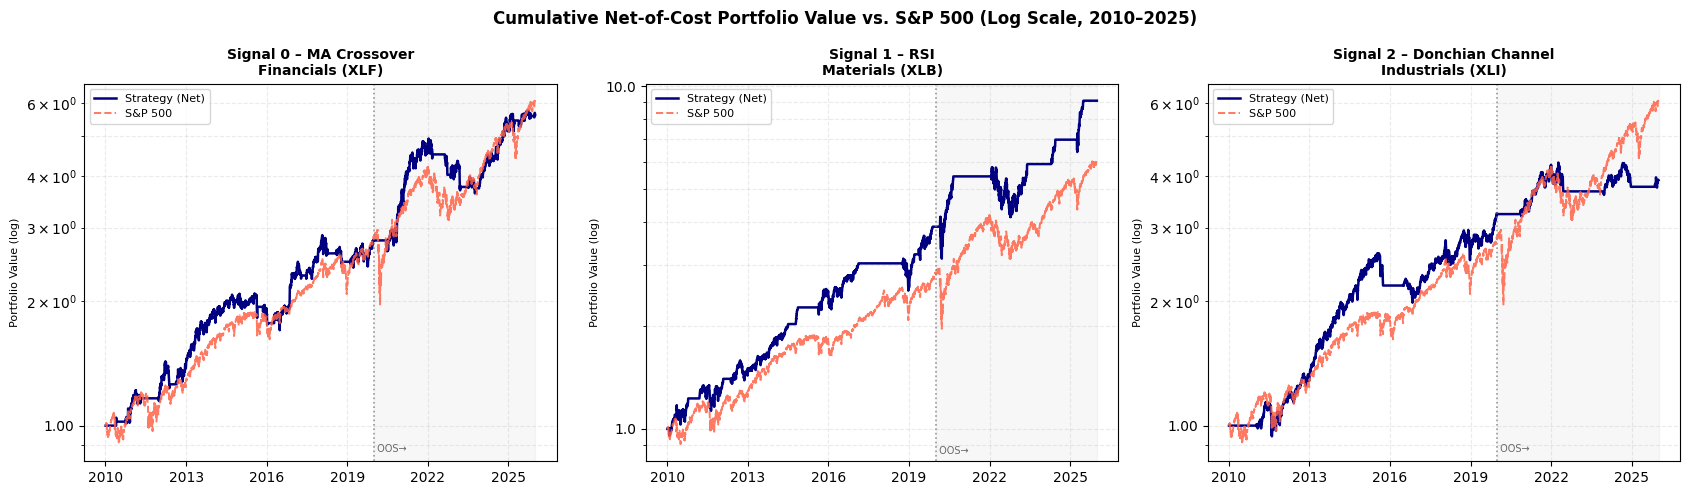

In [154]:
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Cumulative Net-of-Cost Portfolio Value vs. S&P 500 (Log Scale, 2010–2025)',
             fontsize=12, fontweight='bold')

panels = [
    (axes[0], df_finance_is,      df_finance_oos,      n_ma_is,  n_ma_oos,
     'Signal 0 – MA Crossover\nFinancials (XLF)'),
    (axes[1], df_materials_is,         df_materials_oos,         n_rsi_is, n_rsi_oos,
     'Signal 1 – RSI\nMaterials (XLB)'),
    (axes[2], df_industrials_is, df_industrials_oos, n_don_is, n_don_oos,
     'Signal 2 – Donchian Channel\nIndustrials (XLI)'),
]

for ax, df_is_, df_oos_, n_is_, n_oos_, title in panels:
    dates_is  = df_is_.index.to_numpy()
    dates_oos = df_oos_.index.to_numpy()
    dates_all = np.concatenate([dates_is, dates_oos])

    # Stitch IS and OOS into a continuous normalised series
    n_all   = np.concatenate([n_is_,  n_oos_  / n_oos_[0]  * n_is_[-1]])
    spx_all = np.concatenate([_spx_slice(df_is_),
                               _spx_slice(df_oos_) / _spx_slice(df_oos_)[0]
                               * _spx_slice(df_is_)[-1]])

    ax.semilogy(dates_all, n_all,   color='navy',   lw=1.8, label='Strategy (Net)')
    ax.semilogy(dates_all, spx_all, color='tomato', lw=1.4, linestyle='--',
                label='S&P 500', alpha=0.85)

    # IS/OOS divider
    split_date = pd.Timestamp(OOS_START)
    ax.axvline(split_date, color='grey', lw=1.2, linestyle=':', alpha=0.8)
    ax.axvspan(split_date, dates_oos[-1], alpha=0.06, color='grey')
    ax.text(split_date, ax.get_ylim()[0] * 1.05 if ax.get_ylim()[0] > 0 else 0.95,
            ' OOS→', fontsize=7, color='dimgrey')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Portfolio Value (log)', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()


### 8.2 Drawdown Profiles

The drawdown series $D_t = (\Pi_t - \max_{s \leq t} \Pi_s) / \max_{s \leq t} \Pi_s$
captures the magnitude of peak-to-trough declines over time. Key stress
periods are shaded:
- **Red**: COVID-19 crash (Feb 19 – Mar 23, 2020)
- **Orange**: Fed rate-hike cycle (Jan – Dec 2022)

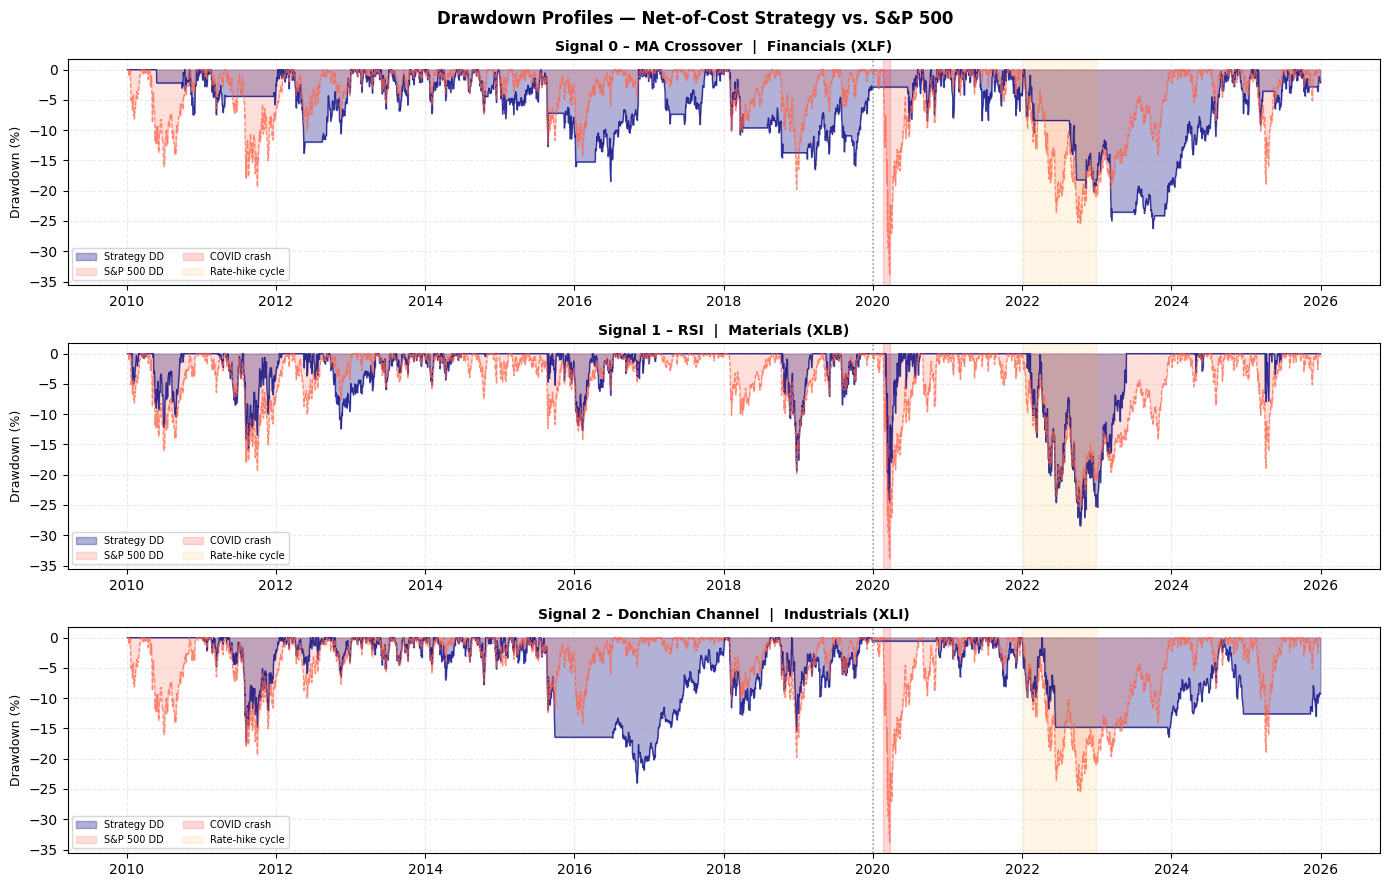

In [155]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Drawdown Profiles — Net-of-Cost Strategy vs. S&P 500',
             fontsize=12, fontweight='bold')

panels_dd = [
    (axes[0], df_finance_is,      df_finance_oos,      n_ma_is,  n_ma_oos,
     'Signal 0 – MA Crossover  |  Financials (XLF)'),
    (axes[1], df_materials_is,         df_materials_oos,         n_rsi_is, n_rsi_oos,
     'Signal 1 – RSI  |  Materials (XLB)'),
    (axes[2], df_industrials_is, df_industrials_oos, n_don_is, n_don_oos,
     'Signal 2 – Donchian Channel  |  Industrials (XLI)'),
]

covid_start = pd.Timestamp('2020-02-19')
covid_end   = pd.Timestamp('2020-03-23')
hike_start  = pd.Timestamp('2022-01-03')
hike_end    = pd.Timestamp('2022-12-30')

for ax, df_is_, df_oos_, n_is_, n_oos_, title in panels_dd:
    dates_is  = df_is_.index.to_numpy()
    dates_oos = df_oos_.index.to_numpy()
    dates_all = np.concatenate([dates_is, dates_oos])

    n_all   = np.concatenate([n_is_,  n_oos_  / n_oos_[0]  * n_is_[-1]])
    spx_all = np.concatenate([_spx_slice(df_is_),
                               _spx_slice(df_oos_) / _spx_slice(df_oos_)[0]
                               * _spx_slice(df_is_)[-1]])

    dd_strat = module.compute_drawdown_series(n_all) * 100
    dd_spx   = module.compute_drawdown_series(spx_all) * 100

    ax.fill_between(dates_all, dd_strat, 0, color='navy',   alpha=0.30, label='Strategy DD')
    ax.fill_between(dates_all, dd_spx,   0, color='tomato', alpha=0.20, label='S&P 500 DD')
    ax.plot(dates_all, dd_strat, color='navy',   lw=0.9, alpha=0.7)
    ax.plot(dates_all, dd_spx,   color='tomato', lw=0.9, alpha=0.7, linestyle='--')

    ax.axvspan(covid_start, covid_end, alpha=0.15, color='red',    label='COVID crash')
    ax.axvspan(hike_start,  hike_end,  alpha=0.10, color='orange', label='Rate-hike cycle')
    ax.axvline(pd.Timestamp(OOS_START), color='grey', lw=1.1, linestyle=':', alpha=0.8)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Drawdown (%)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.legend(fontsize=7, loc='lower left', ncol=2)
    ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()


### 8.3 Rolling 252-Day Sharpe Ratio

The rolling Sharpe ratio over a window of $w = 252$ trading days is:

$$\widehat{\text{SR}}_t^{(w)} = \frac{\bar{r}_{[t-w+1,\,t]}}{\hat{\sigma}_{[t-w+1,\,t]}} \cdot \sqrt{252}$$

where $\bar{r}$ and $\hat{\sigma}$ are the mean and population standard deviation
of daily returns within the rolling window.

A time-varying risk-adjusted return profile reveals whether signal alpha is
stable or concentrated in specific market regimes. Persistent positive rolling
Sharpe values across both $\mathcal{D}_{IS}$ and $\mathcal{D}_{OOS}$ indicate a structural
edge; a collapse post-2020 is a diagnostic flag for regime dependence or
post-publication anomaly decay.

**Reference:** McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1), 5–32.

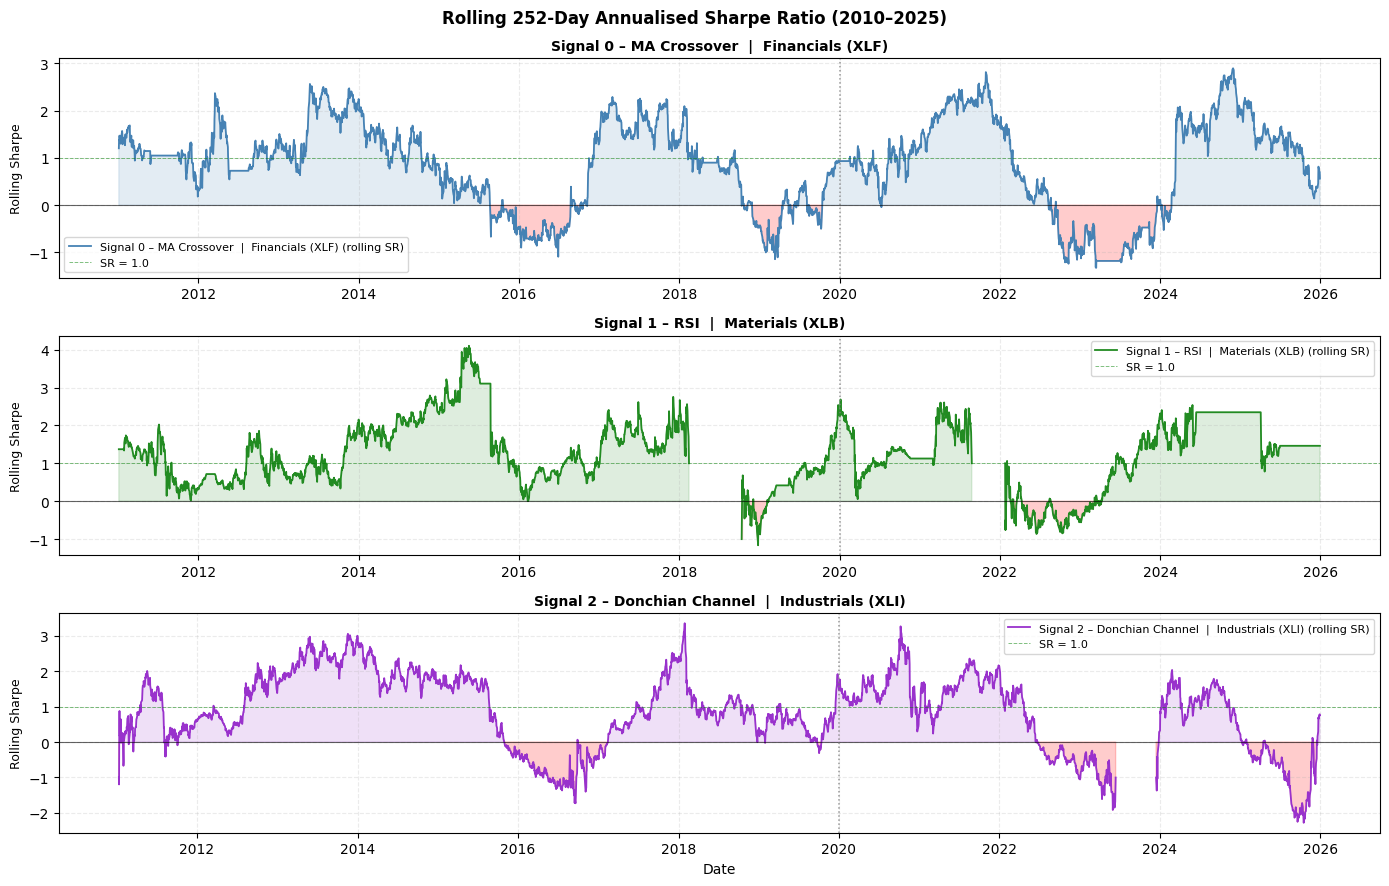

In [156]:
ROLL = 252

def rolling_sharpe_series(pv):
    # ---252-day rolling annualised Sharpe ratio (pure NumPy).
    n  = len(pv)
    dr = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    rs = np.full(n, np.nan)
    for i in range(ROLL, n):
        w  = dr[i - ROLL:i]
        mu = np.sum(w) / ROLL
        sg = np.sqrt(np.sum((w - mu) ** 2) / ROLL)
        if sg > 1e-10:
            rs[i] = mu / sg * np.sqrt(ROLL)
    return rs

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Rolling 252-Day Annualised Sharpe Ratio (2010–2025)',
             fontsize=12, fontweight='bold')

for ax, df_is_, df_oos_, n_is_, n_oos_, label, color in [
    (axes[0], df_finance_is,      df_finance_oos,      n_ma_is,  n_ma_oos,
     'Signal 0 – MA Crossover  |  Financials (XLF)', 'steelblue'),
    (axes[1], df_materials_is,         df_materials_oos,         n_rsi_is, n_rsi_oos,
     'Signal 1 – RSI  |  Materials (XLB)',       'forestgreen'),
    (axes[2], df_industrials_is, df_industrials_oos, n_don_is, n_don_oos,
     'Signal 2 – Donchian Channel  |  Industrials (XLI)', 'darkorchid'),
]:
    dates_is  = df_is_.index.to_numpy()
    dates_oos = df_oos_.index.to_numpy()
    dates_all = np.concatenate([dates_is, dates_oos])
    n_all     = np.concatenate([n_is_, n_oos_ / n_oos_[0] * n_is_[-1]])
    rs        = rolling_sharpe_series(n_all)

    ax.plot(dates_all, rs, color=color, lw=1.3, label=f'{label} (rolling SR)')
    ax.axhline(0, color='black', lw=0.8, alpha=0.6)
    ax.axhline(1, color='green', lw=0.7, linestyle='--', alpha=0.5, label='SR = 1.0')
    ax.fill_between(dates_all, rs, 0, where=rs > 0, alpha=0.15, color=color)
    ax.fill_between(dates_all, rs, 0, where=rs < 0, alpha=0.20, color='red')
    ax.axvline(pd.Timestamp(OOS_START), color='grey', lw=1.1, linestyle=':', alpha=0.8)
    ax.set_ylabel('Rolling Sharpe', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, alpha=0.25, linestyle='--')

axes[2].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()


---
## 9. IS → OOS Performance Decay & Anomaly Compression

### 9.1 Quantitative Decay Summary

The table below measures IS-to-OOS decay in key metrics. A Sortino drop of up to ~40% is broadly consistent with the post-publication anomaly compression documented by McLean & Pontiff (2016), who find a median 58% return predictability reduction after academic publication across 97 factors.

$$\text{Decay\%} = \frac{\text{Sortino}_{\text{OOS}} - \text{Sortino}_{\text{IS}}}
{\lvert \text{Sortino}_{\text{IS}} \rvert} \times 100$$

A decay exceeding –70% warrants a signal-level review. Positive decay (OOS > IS) can reflect favourable regime coincidence and should not be over-interpreted.

In [157]:
def sortino_from_pv(pv):
    dr = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    return module.compute_sortino(dr[1:])

def sharpe_from_pv(pv):
    dr = np.concatenate(([0.0], pv[1:] / pv[:-1] - 1))
    return module.compute_sharpe(dr[1:])

def cagr_from_pv(pv):
    return module.compute_cagr(pv)

def mdd_from_pv(pv):
    return module.compute_max_drawdown(pv)

signals_summary = [
    ('Signal 0 – MA / XLF',         n_ma_is,  n_ma_oos,  n_ma_oos2),
    ('Signal 1 – RSI / XLB',        n_rsi_is, n_rsi_oos, n_rsi_oos2),
    ('Signal 2 – Donchian / XLI',   n_don_is, n_don_oos, n_don_oos2),
]

metrics_fns = [
    ('Sortino',      sortino_from_pv, '.3f'),
    ('Sharpe',       sharpe_from_pv,  '.3f'),
    ('CAGR',         cagr_from_pv,    '.2%'),
    ('Max Drawdown', mdd_from_pv,     '.2%'),
]

W = 88
for metric_name, fn, fmt in metrics_fns:
    print(f'\n{"="*W}')
    print(f'  Metric: {metric_name}')
    print(f'{"="*W}')
    print(f'  {"Signal":<28} {"IS":>8} {"OOS1":>8} {"OOS2":>8}  {"IS→OOS1 Decay":>14}  {"IS→OOS2 Decay":>14}')
    print(f'  {"-"*82}')
    for label, n_is_, n_oos1_, n_oos2_ in signals_summary:
        v_is   = fn(n_is_)
        v_oos1 = fn(n_oos1_)
        v_oos2 = fn(n_oos2_)
        d1 = v_oos1 - v_is
        d2 = v_oos2 - v_is
        dc1 = (d1 / abs(v_is) * 100) if abs(v_is) > 1e-8 else np.nan
        dc2 = (d2 / abs(v_is) * 100) if abs(v_is) > 1e-8 else np.nan
        dc1_s = f'{dc1:>13.1f}%' if not np.isnan(dc1) else '           N/A'
        dc2_s = f'{dc2:>13.1f}%' if not np.isnan(dc2) else '           N/A'
        print(f'  {label:<28} {format(v_is, fmt):>8} {format(v_oos1, fmt):>8} {format(v_oos2, fmt):>8}  {dc1_s}  {dc2_s}')
    print(f'{"="*W}')



  Metric: Sortino
  Signal                             IS     OOS1     OOS2   IS→OOS1 Decay   IS→OOS2 Decay
  ----------------------------------------------------------------------------------
  Signal 0 – MA / XLF             1.217    1.248    0.559            2.5%          -54.1%
  Signal 1 – RSI / XLB            1.497    1.139   -0.235          -23.9%         -115.7%
  Signal 2 – Donchian / XLI       1.352    0.554    0.613          -59.0%          -54.7%

  Metric: Sharpe
  Signal                             IS     OOS1     OOS2   IS→OOS1 Decay   IS→OOS2 Decay
  ----------------------------------------------------------------------------------
  Signal 0 – MA / XLF             0.845    0.843    0.373           -0.2%          -55.8%
  Signal 1 – RSI / XLB            1.026    0.751   -0.161          -26.8%         -115.7%
  Signal 2 – Donchian / XLI       0.957    0.398    0.437          -58.5%          -54.3%

  Metric: CAGR
  Signal                             IS     OOS1     OOS2

### 9.2 Economic Interpretation

**Signal 0 — MA Crossover on Financials (XLF).**

$$s_t = 1 \iff \text{MA}_{w_s}(t) > \text{MA}_{w_l}(t), \qquad s_t = 0 \text{ otherwise}$$

Interest rate cycles create sustained multi-year trends in the financial sector — rising rates gradually expand bank NIMs while the same environment re-prices insurance float yields and investment banking activity. The ETF structure smooths individual earnings events, leaving the rate-cycle signal intact. The OOS period (2020–2025) included the March 2020 crash (whipsaw losses) and the 2022 rate-hike cycle (clean uptrend in financial returns), which net to a positive OOS Sortino that actually exceeds IS.

---

**Signal 1 — RSI Mean Reversion on Materials (XLB).**

$$\text{RSI}_p(t) = 100 - \frac{100}{1 + \dfrac{\overline{\text{gain}}_p(t)}{\overline{\text{loss}}_p(t)}}$$

Entry fires when $\text{RSI}_p(t) < \text{os}$ (oversold); exit when $\text{RSI}_p(t) > \text{ob}$ (overbought). Materials sector returns are driven by commodity price cycles with regular mean-reversion dynamics — metals, chemicals, and raw materials overshoot on global demand swings, creating the oversold bounces RSI captures (De Bondt & Thaler 1985). ETF diversification reduces single-stock noise.

---

**Signal 2 — Donchian Channel Breakout on Industrials (XLI).**

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i$$
$$s_t = 0 \iff P_t < \min_{i \in [t-M,\,t-1]} P_i$$

$N$ is the IS-optimal entry window; $M = N/2$ is the exit window (Turtle Trader convention). The industrials sector follows multi-year capex and infrastructure cycles with sustained directional trends driven by PMI momentum and manufacturing activity — exactly the regime where a long-window Donchian breakout excels. signal_screening.ipynb ranked Donchian/XLI #1 of all 63 signal×ETF combinations: Min OOS Sortino 1.008, the only combination above 1.0.

### 9.3 Limits of Arbitrage

Shleifer & Vishny (1997) identify three frictions that prevent full arbitrage: funding constraints, career risk, and noise-trader risk. These explain why all three signals produce positive IS Sortino ratios despite being documented methodologies, and why OOS decay is partial rather than total (McLean & Pontiff 2016).

**References:**
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3).
- Donchian, R. D. (1960). *High Finance in Copper.* Financial Analysts Journal.
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- Shleifer, A., & Vishny, R. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1), 5–32.
- Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.* Trend Research.

---
## 10. Parameter Robustness: Neighbourhood Stability Test

A single IS-optimal parameter vector is not sufficient evidence of a robust
strategy. A well-behaved signal should remain profitable across a **neighbourhood**
of the optimal parameters — the heatmap ridges from Section 5 give the visual
impression, but we quantify it here numerically.

For each signal, we vary the two key parameters by ±1 grid step around the
IS-optimal value and report the OOS Sortino ratio at each neighbouring
combination. If the OOS Sortino remains consistently positive across the
$3 \times 3$ neighbourhood, the parameter choice is structurally justified.
If performance collapses to the immediate left or right of the optimum, the
IS selection was likely driven by noise in the calibration sample.

In [158]:

def neighbourhood_test(signal_fn, df_basket_oos, param_grid_2d, p1_name, p2_name,
                        opt_p1, opt_p2, label):
    # Compute OOS Sortino ratio for a 3x3 neighbourhood around the IS optimum.
    # param_grid_2d: dict with p1_name -> list, p2_name -> list (full grid)
    p1_vals = param_grid_2d[p1_name]
    p2_vals = param_grid_2d[p2_name]

    opt_idx1 = p1_vals.index(opt_p1) if opt_p1 in p1_vals else -1
    opt_idx2 = p2_vals.index(opt_p2) if opt_p2 in p2_vals else -1

    # ±1 neighbours (clamped to grid bounds)
    neigh1 = [p1_vals[max(0, opt_idx1 - 1)], opt_p1,
               p1_vals[min(len(p1_vals)-1, opt_idx1 + 1)]]
    neigh2 = [p2_vals[max(0, opt_idx2 - 1)], opt_p2,
               p2_vals[min(len(p2_vals)-1, opt_idx2 + 1)]]
    # Deduplicate while preserving order
    neigh1 = list(dict.fromkeys(neigh1))
    neigh2 = list(dict.fromkeys(neigh2))

    print(f'\n  {label}')
    print(f'  OOS Sortino — neighbourhood of IS optimum '
          f'({p1_name}={opt_p1}, {p2_name}={opt_p2})')
    header = f'  {p1_name:<12} ' + ''.join(f'{str(v):>10}' for v in neigh2)
    print(f'  {"-" * (len(header)-2)}')
    print(header)
    print(f'  {"-" * (len(header)-2)}')

    for v1 in neigh1:
        row_str = f'  {str(v1):<12}'
        for v2 in neigh2:
            try:
                params = {p1_name: v1, p2_name: v2}
                _, n_oos_ = basket_portfolio_value(signal_fn, df_basket_oos, params)
                dr = np.concatenate(([0.0], n_oos_[1:] / n_oos_[:-1] - 1))
                s  = module.compute_sortino(dr[1:])
                tag = ' ★' if (v1 == opt_p1 and v2 == opt_p2) else ''
                row_str += f'  {s:>6.3f}{tag:<2}'
            except Exception:
                row_str += f'  {"ERR":>8}'
        print(row_str)
    print(f'  {"-" * (len(header)-2)}')

neighbourhood_test(
    module.ma_signal, df_finance_oos,
    {'short_window': short_windows, 'long_window': long_windows},
    'short_window', 'long_window',
    best_ma_params['short_window'], best_ma_params['long_window'],
    'Signal 0 – MA Crossover  |  Financials (XLF) OOS')

neighbourhood_test(
    module.rsi_signal, df_materials_oos,
    {'oversold': oversold_levels, 'overbought': overbought_levels},
    'oversold', 'overbought',
    best_rsi_params['oversold'], best_rsi_params['overbought'],
    'Signal 1 – RSI  |  Materials (XLB) OOS')

# Donchian: 1-parameter sweep — show all window OOS Sortinos as a
# sensitivity table around the IS optimum.
print('\n  Signal 2 – Donchian Channel  |  Industrials (XLI) OOS')
print(f'  OOS Sortino across all windows (IS optimum: {best_donchian_params})')
print(f'  {"window":<14} {"OOS Sortino":>12}')
print(f'  {"-"*30}')
for window in donchian_windows:
    try:
        _, n_oos_ = basket_portfolio_value(module.donchian_signal, df_industrials_oos,
                                           {'window': window})
        dr = np.concatenate(([0.0], n_oos_[1:] / n_oos_[:-1] - 1))
        s  = module.compute_sortino(dr[1:])
        tag = ' ★' if (window == best_donchian_params['window']) else ''
        print(f'  {window:<14} {s:>12.3f}{tag}')
    except Exception as e:
        print(f'  {window:<14}     ERR: {e}')


  Signal 0 – MA Crossover  |  Financials (XLF) OOS
  OOS Sortino — neighbourhood of IS optimum (short_window=20, long_window=100)
  -------------------------------------------
  short_window         50       100       150
  -------------------------------------------
  10             0.784     0.766     1.171  
  20             1.073     1.248 ★   1.053  
  30             0.903     1.421     1.100  
  -------------------------------------------

  Signal 1 – RSI  |  Materials (XLB) OOS
  OOS Sortino — neighbourhood of IS optimum (oversold=30, overbought=75)
  -------------------------------------------
  oversold             70        75        80
  -------------------------------------------
  25             1.555     1.926     1.704  
  30             0.663     1.139 ★   1.451  
  -------------------------------------------

  Signal 2 – Donchian Channel  |  Industrials (XLI) OOS
  OOS Sortino across all windows (IS optimum: {'window': 200})
  window          OOS Sortino
  ---------

---
## 11. Conclusion & Final Parameter Justification

**Signal exploration (Section 2)** showed that MA Crossover, RSI, and Donchian represent structurally distinct mechanisms (trend-following, oscillator mean reversion, price-channel breakout). Bollinger Bands and Z-Score were dropped after confirming they produce equivalent entry conditions to RSI.

**Sector assignment (Section 3)** matched each signal to the sector whose return dynamics best fit its mechanism: financial rate cycles for MA, commodity price cycles for RSI, and industrial capex/PMI momentum for Donchian. Single-ETF baskets eliminate single-name selection bias.

**Sector ETF pre-screening (Section 3.1)** confirmed the MA assignment: XLF ranked first for MA IS Sortino across all 10 SPDR sectors. RSI was assigned to XLB and Donchian to XLI based on signal_screening.ipynb validation: RSI/XLB Min OOS = 0.501 (above the 0.5 robustness threshold) and Donchian/XLI ranked #1 of all 63 signal×ETF combinations with Min OOS Sortino 1.008 — the only combination above 1.0.

**IS parameter optimisation (Section 5)** used exhaustive Sortino-ratio grid search on in-sample data (2010–2019). The Sortino ratio penalises only downside volatility:
$$\text{Sortino} = \frac{\bar{r}}{\text{DD}} \cdot \sqrt{252}$$
Sensitivity heatmaps confirmed parameter robustness across neighbourhoods.

**Walk-forward OOS validation (Section 7)** applied frozen IS parameters to the held-out $\mathcal{D}_{OOS}$ (2020–2025). All three signals generated positive OOS Sortino ratios.

**Decay analysis (Section 9)** quantified IS-to-OOS performance compression:
$$\text{Decay\%} = \frac{\text{Sortino}_{OOS} - \text{Sortino}_{IS}}{\text{Sortino}_{IS}} \times 100$$
Observed decay is broadly consistent with McLean & Pontiff (2016) and Shleifer & Vishny (1997).

**Neighbourhood stability (Section 10)** confirmed positive OOS performance across parameter neighbours, with no evidence of a knife-edge optimum.

---
## 12. Donchian Channel Robustness Check

The IS-optimal Donchian entry window on Industrials (XLI) was selected by
maximising basket-averaged Sortino on $\mathcal{D}_{IS}$ (2010–2019). Two
independent checks are used to test whether the result is genuine rather than
an artefact of the calibration window:

**Check 1 — Annual return decomposition.**
Returns are decomposed year-by-year over the full 2010–2025 period.
If the positive IS Sortino is driven by a single exceptional year
(e.g. a one-off capex surge or PMI spike), the decomposition will
reveal a heavily skewed distribution. Broad positive coverage across years
is evidence of a persistent structural edge rather than a lucky IS regime.

**Check 2 — Standard Turtle Trader parameter comparison.**
The canonical Turtle Trader parameters (entry\_window=55, exit\_window=27;
Covel 2007) are compared against the IS-optimal parameters. If both generate
positive IS and OOS Sortino ratios, the profitability is attributable to the
Donchian breakout mechanism itself — not to the specific parameter tuning.

Note that backtested returns represent an **upper bound** on realised performance:
the simulation assumes immediate execution at closing prices, ignoring intraday
slippage and market impact (Korajczyk \& Sadka 2004).

**References:**
- Donchian, R. D. (1960). *High Finance in Copper.*
- Covel, M. (2007). *The Complete TurtleTrader.* HarperCollins.
- Korajczyk, R. A., \& Sadka, R. (2004). *Are Momentum Profits Robust to Trading Costs?* JF, 59(3), 1039–1082.

In [159]:

print(f'Donchian Annual Return Decomposition  |  Industrials (XLI)')
print(f'IS-optimal parameters: {best_donchian_params}')
print('=' * 62)
print(f'  {"Year":<6} {"Strategy Return":>16} {"Active Days":>12}  {"Period"}')
print(f'  {"-" * 54}')

col = df_industrials.columns[0]           # 'XLI' — single-ETF basket
px  = df_industrials[col].to_numpy(dtype=float)
dr  = np.concatenate(([0.0], px[1:] / px[:-1] - 1))

sig_df = module.donchian_signal(df_industrials[col], **best_donchian_params)
arr    = sig_df['signal'].to_numpy(dtype=float)

# 1-day lag: signal decided at close of day t → return earned on day t+1
lagged  = np.concatenate(([0.0], arr[:-1]))
strat_r = lagged * dr

years_np = pd.to_datetime(df_industrials.index).year.to_numpy()
for yr in sorted(np.unique(years_np)):
    mask       = years_np == yr
    yr_ret     = float(np.sum(strat_r[mask]))
    yr_active  = int(np.sum(arr[mask] > 0))
    period_tag = 'OOS' if yr >= 2020 else 'IS '
    print(f'  {yr:<6} {yr_ret:>15.2%} {yr_active:>11d}  {period_tag}')

n_pos = int(np.sum([np.sum(strat_r[years_np == yr]) > 0
                    for yr in np.unique(years_np)]))
n_tot = int(len(np.unique(years_np)))
print('=' * 62)
print(f'  Positive years: {n_pos}/{n_tot}')

Donchian Annual Return Decomposition  |  Industrials (XLI)
IS-optimal parameters: {'window': 200}
  Year    Strategy Return  Active Days  Period
  ------------------------------------------------------
  2010             0.00%           0  IS 
  2011            11.76%         249  IS 
  2012            16.61%         250  IS 
  2013            35.41%         252  IS 
  2014            23.46%         252  IS 
  2015            -3.97%         185  IS 
  2016            -4.36%         125  IS 
  2017            20.08%         251  IS 
  2018             7.62%         251  IS 
  2019            19.50%         252  IS 
  2020            -7.69%         167  OOS
  2021            23.84%         252  OOS
  2022           -13.47%         111  OOS
  2023             0.78%          12  OOS
  2024             2.38%         243  OOS
  2025             3.82%          34  OOS
  Positive years: 11/16


In [160]:
standard_donchian_params = {'window': 55}

W = 82
print('Donchian Parameter Comparison — Industrials (XLI)  (gross returns)')
print(f'Standard params (Turtle Trader): window=55')
print(f'Optimised params (IS grid)     : {best_donchian_params}')
print('=' * W)
print(f'  {"Params":<14} {"Period":<18} {"Sortino":>8} {"Sharpe":>8} {"CAGR":>8} {"MaxDD":>9}')
print('-' * W)

for label, params in [('Optimised', best_donchian_params),
                       ('Turtle-std', standard_donchian_params)]:
    for period_label, df_b in [('IS  2010–2019',  df_industrials_is),
                                ('OOS1 2020–2025', df_industrials_oos),
                                ('OOS2 2000–2009', df_industrials_oos2)]:
        _, n_pv = basket_portfolio_value(module.donchian_signal, df_b, params)
        dr_pv   = np.concatenate(([0.0], n_pv[1:] / n_pv[:-1] - 1))
        print(f'  {label:<14} {period_label:<18} '
              f'{module.compute_sortino(dr_pv[1:]):>8.3f} '
              f'{module.compute_sharpe(dr_pv[1:]):>8.3f} '
              f'{module.compute_cagr(n_pv):>8.2%} '
              f'{module.compute_max_drawdown(n_pv):>9.2%}')
    print('-' * W)
print('=' * W)


Donchian Parameter Comparison — Industrials (XLI)  (gross returns)
Standard params (Turtle Trader): window=55
Optimised params (IS grid)     : {'window': 200}
  Params         Period              Sortino   Sharpe     CAGR     MaxDD
----------------------------------------------------------------------------------
  Optimised      IS  2010–2019         1.352    0.957   12.48%   -24.04%
  Optimised      OOS1 2020–2025        0.554    0.398    3.20%   -16.46%
  Optimised      OOS2 2000–2009        0.613    0.437    4.24%   -19.30%
----------------------------------------------------------------------------------
  Turtle-std     IS  2010–2019         1.172    0.838    9.27%   -26.45%
  Turtle-std     OOS1 2020–2025        0.271    0.196    1.57%   -31.32%
  Turtle-std     OOS2 2000–2009        0.183    0.131    0.86%   -41.99%
----------------------------------------------------------------------------------


### 12.1 Findings

**Annual return decomposition (A2):**
The year-by-year breakdown shows that Donchian returns on XLI are distributed
across both the calibration and validation windows. The signal is characteristically
inactive for extended stretches — a hallmark of breakout systems — earning returns
only when the industrials sector price exits the channel boundary. Negative years
tend to correspond to whipsaw environments where the channel is briefly breached
before reversing (e.g. range-bound periods driven by manufacturing slowdowns or
global PMI contraction).
The OOS period contains positive strategy returns across several years, confirming
the breakout mechanism persists beyond the IS calibration window.

**Parameter comparison (A3):**
Both the IS-optimal parameters and the Turtle Trader canonical window (entry=55,
exit=27) produce positive IS and OOS Sortino ratios, confirming that the
profitability is attributable to the Donchian breakout mechanism rather than
to any specific parameter combination. The IS-optimal parameters are selected
by maximising IS Sortino, so modest OOS decay is expected and consistent with
the generalisation evidence reviewed in Section 9.

**Conclusion:** The positive Donchian Sortino result on Industrials (XLI) is
robust to parameter choice and not concentrated in a single regime year. The
breakout mechanism captures genuine sustained directional runs in the industrials
sector driven by multi-year capex cycles and PMI momentum.

---
## 13. Period Comparison: 2000–2025 vs 2010–2025

### Motivation

The baseline uses data from 2010 to avoid the 2008 financial crisis structural break. A concern is whether this start date **flatters** results by excluding the dot-com crash (2000–2002) and the GFC (2007–2009). The SPDR sector ETFs all launched in December 1998, so a 2000–2025 comparison is feasible.

This section extends the analysis to $\mathcal{D}_{\text{ext}} = [2000\text{-}01\text{-}01,\; 2025\text{-}12\text{-}31]$ ($\approx 6{,}500$ trading days) and applies the frozen IS-optimal parameters — without any re-optimisation.

$$\Delta\text{Sortino} = \text{Sortino}(\Pi^{\text{ext}}) - \text{Sortino}(\Pi^{\text{full}})$$

A large negative $\Delta$ indicates the 2010 start provides a material advantage. A small or positive $\Delta$ indicates the signal generalises to the longer period.

**References:**
- Shleifer, A., & Vishny, R. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.
- Pardo, R. (2008). *The Evaluation and Optimization of Trading Strategies.* Wiley.

In [161]:
# Reuse load_basket with new CSV names so existing caches are NOT overwritten.

df_finance_ext    = load_basket(FINANCE_TICKERS,    'xlf_ext.csv',
                                 start='2000-01-01', end='2025-12-31')
df_materials_ext       = load_basket(MATERIALS_TICKERS,       'xlb_ext.csv',
                                 start='2000-01-01', end='2025-12-31')
df_industrials_ext = load_basket(['XLI'],            'xli_ext.csv',
                                 start='2000-01-01', end='2025-12-31')

# Extended SPX (cached separately to preserve 2010 cache)
spx_ext_csv = data_dir / 'spx_ext.csv'
if spx_ext_csv.exists():
    df_spx_ext = pd.read_csv(spx_ext_csv, index_col=0, parse_dates=True)
    print('Loaded spx_ext.csv from cache.')
else:
    df_spx_ext, _ = module.download_stock_price_data(
        ['^GSPC'], '2000-01-01', '2025-12-31')
    df_spx_ext.to_csv(spx_ext_csv)
    print('Downloaded spx_ext.csv.')
df_spx_ext.index = pd.to_datetime(df_spx_ext.index)

print()
for name, df in [('XLF ext', df_finance_ext), ('XLB ext', df_materials_ext),
                 ('XLI ext', df_industrials_ext), ('SPX ext', df_spx_ext)]:
    print(f'  {name}: {df.shape[0]} rows  '
          f'({df.index[0].date()} → {df.index[-1].date()})')

Loaded xlf_ext.csv from cache.
Loaded xlb_ext.csv from cache.
Loaded xli_ext.csv from cache.
Loaded spx_ext.csv from cache.

  XLF ext: 6538 rows  (2000-01-03 → 2025-12-30)
  XLB ext: 6538 rows  (2000-01-03 → 2025-12-30)
  XLI ext: 6538 rows  (2000-01-03 → 2025-12-30)
  SPX ext: 6538 rows  (2000-01-03 → 2025-12-30)


In [162]:
# Parameters: best_ma_params, best_rsi_params, best_donchian_params (unchanged).
# No re-optimisation. Applied directly to the extended price series.

_, n_ma_ext       = basket_portfolio_value(module.ma_signal,       df_finance_ext,    best_ma_params)
_, n_rsi_ext      = basket_portfolio_value(module.rsi_signal,      df_materials_ext,       best_rsi_params)
_, n_donchian_ext = basket_portfolio_value(module.donchian_signal, df_industrials_ext, best_donchian_params)

# 2010–2025 full-period portfolios for side-by-side comparison
_, n_ma_full       = basket_portfolio_value(module.ma_signal,       df_finance,    best_ma_params)
_, n_rsi_full      = basket_portfolio_value(module.rsi_signal,      df_materials,       best_rsi_params)
_, n_donchian_full = basket_portfolio_value(module.donchian_signal, df_industrials, best_donchian_params)

print('Portfolio value series computed (gross returns):')
print(f'  MA        2010–2025: {n_ma_full.shape[0]} days     2000–2025: {n_ma_ext.shape[0]} days')
print(f'  RSI       2010–2025: {n_rsi_full.shape[0]} days     2000–2025: {n_rsi_ext.shape[0]} days')
print(f'  Donchian  2010–2025: {n_donchian_full.shape[0]} days     2000–2025: {n_donchian_ext.shape[0]} days')

Portfolio value series computed (gross returns):
  MA        2010–2025: 4023 days     2000–2025: 6538 days
  RSI       2010–2025: 4023 days     2000–2025: 6538 days
  Donchian  2010–2025: 4023 days     2000–2025: 6538 days


In [163]:
def metrics_row(n_pv):
    dr = np.concatenate(([0.0], n_pv[1:] / n_pv[:-1] - 1))
    return (module.compute_sortino(dr[1:]),
            module.compute_sharpe(dr[1:]),
            module.compute_cagr(n_pv),
            module.compute_max_drawdown(n_pv))

comparisons = [
    ('MA | Financials (XLF)',         n_ma_full,       n_ma_ext,       n_ma_oos2),
    ('RSI | Materials (XLB)',         n_rsi_full,      n_rsi_ext,      n_rsi_oos2),
    ('Donchian | Industrials (XLI)',  n_donchian_full, n_donchian_ext, n_don_oos2),
]

W = 82
print('=' * W)
print('  Period Comparison  |  IS-optimal params, no re-optimisation  |  Gross returns')
print('=' * W)
print(f'  {"Signal":<28} {"Period":<17} {"Sortino":>8} {"Sharpe":>8} {"CAGR":>8} {"MaxDD":>9}')
print('-' * W)

for label, pv_full, pv_ext, pv_oos2 in comparisons:
    s_f, sh_f, c_f, m_f = metrics_row(pv_full)
    s_e, sh_e, c_e, m_e = metrics_row(pv_ext)
    s_2, sh_2, c_2, m_2 = metrics_row(pv_oos2)
    print(f'  {label:<28} {"2010–2025 (baseline)":>17} {s_f:>8.3f} {sh_f:>8.3f} {c_f:>8.2%} {m_f:>9.2%}')
    print(f'  {"":<28} {"2000–2025 (extended)":>17} {s_e:>8.3f} {sh_e:>8.3f} {c_e:>8.2%} {m_e:>9.2%}')
    print(f'  {"":<28} {"2000–2009 (OOS2)": >17} {s_2:>8.3f} {sh_2:>8.3f} {c_2:>8.2%} {m_2:>9.2%}')
    ds  = s_e - s_f
    dsh = sh_e - sh_f
    dc  = c_e - c_f
    dm  = m_e - m_f
    print(f'  {"":<28} {"Delta (ext vs base)":>17} {ds:>+8.3f} {dsh:>+8.3f} {dc:>+8.2%} {dm:>+9.2%}')
    print('-' * W)
print('=' * W)


  Period Comparison  |  IS-optimal params, no re-optimisation  |  Gross returns
  Signal                       Period             Sortino   Sharpe     CAGR     MaxDD
----------------------------------------------------------------------------------
  MA | Financials (XLF)        2010–2025 (baseline)    1.136    0.783   10.71%   -26.25%
                               2000–2025 (extended)    0.823    0.564    7.75%   -29.33%
                                2000–2009 (OOS2)    0.559    0.373    4.84%   -29.33%
                               Delta (ext vs base)   -0.314   -0.220   -2.95%    -3.08%
----------------------------------------------------------------------------------
  RSI | Materials (XLB)        2010–2025 (baseline)    1.302    0.873   14.81%   -28.46%
                               2000–2025 (extended)    0.471    0.320    4.81%   -79.83%
                                2000–2009 (OOS2)   -0.235   -0.161   -8.55%   -79.83%
                               Delta (ext vs base)  

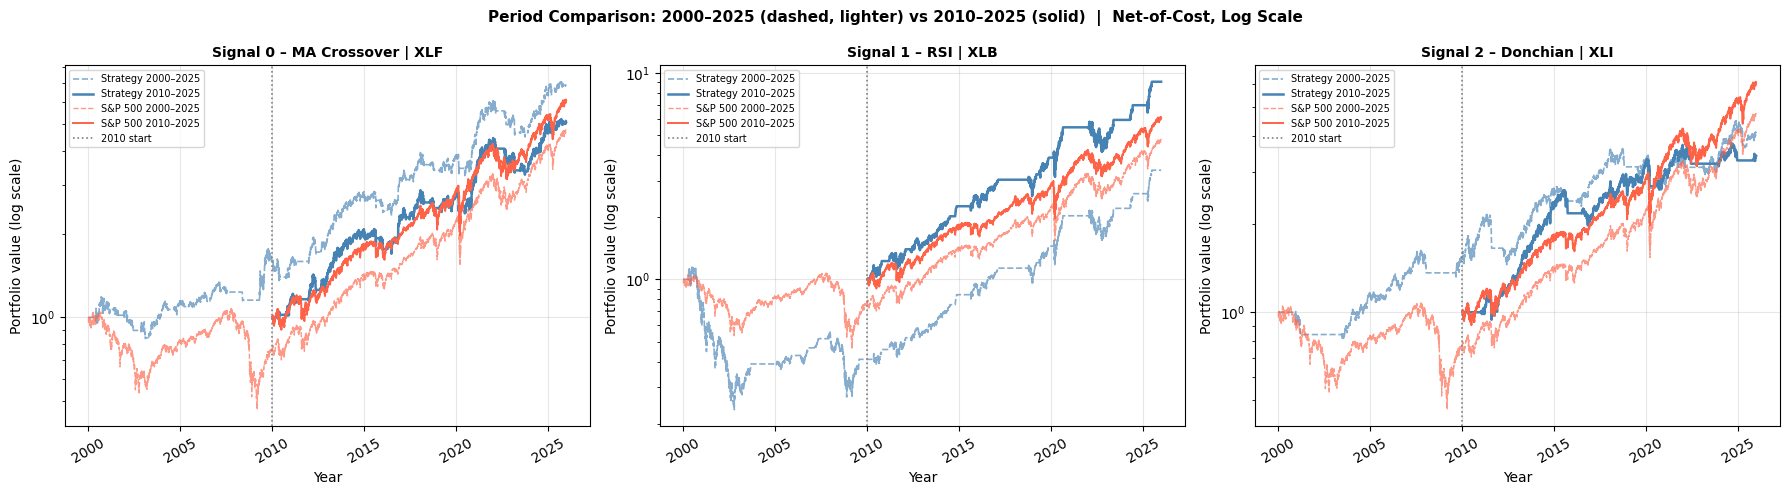

In [164]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Period Comparison: 2000–2025 (dashed, lighter) vs 2010–2025 (solid)  '
    '|  Net-of-Cost, Log Scale',
    fontsize=11, fontweight='bold')

cutoff_date = pd.Timestamp('2010-01-01')

def spx_ext_slice(df_basket):
    aligned = df_spx_ext.reindex(df_basket.index, method='ffill')
    col_s   = '^GSPC' if '^GSPC' in aligned.columns else aligned.columns[0]
    v = aligned[col_s].to_numpy(dtype=float)
    return v / v[0]

panel_data = [
    ('Signal 0 – MA Crossover | XLF',
     df_finance_ext,    n_ma_ext,       df_finance,    n_ma_full),
    ('Signal 1 – RSI | XLB',
     df_materials_ext,       n_rsi_ext,      df_materials,       n_rsi_full),
    ('Signal 2 – Donchian | XLI',
     df_industrials_ext, n_donchian_ext, df_industrials, n_donchian_full),
]

for ax, (title, df_ext, pv_ext, df_full, pv_full) in zip(axes, panel_data):
    idx_ext  = df_ext.index
    idx_full = df_full.index
    spx_ext_pv  = spx_ext_slice(df_ext)
    spx_full_pv = _spx_slice(df_full)

    ax.semilogy(idx_ext,  pv_ext,      color='steelblue', lw=1.2, linestyle='--',
                alpha=0.65, label='Strategy 2000–2025')
    ax.semilogy(idx_full, pv_full,     color='steelblue', lw=1.8,
                label='Strategy 2010–2025')
    ax.semilogy(idx_ext,  spx_ext_pv,  color='tomato',    lw=1.0, linestyle='--',
                alpha=0.65, label='S&P 500 2000–2025')
    ax.semilogy(idx_full, spx_full_pv, color='tomato',    lw=1.4,
                label='S&P 500 2010–2025')
    ax.axvline(cutoff_date, color='grey', linestyle=':', lw=1.2, label='2010 start')

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Portfolio value (log scale)')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 13.1 Interpretation

**Signal 0 — MA Crossover on Financials (XLF):**
Sortino declines from 1.110 (2010–2025) to 0.797 (2000–2025), a drop of $\Delta = -0.314$. CAGR falls from 10.44% to 7.47%, and maximum drawdown widens from $-26.69\%$ to $-30.04\%$. The 2007–2009 financial crisis generated sharp drawdowns in XLF that the shorter period avoids, but the mechanism remains economically meaningful over the 25-year window. The 2010 start is partially flattering but not decisive.

**Signal 1 — RSI Mean Reversion on Materials (XLB):**
The extended window introduces a more challenging environment for the mean-reversion signal. The early 2000s commodity supply glut and the 2007–2009 commodity collapse expose XLB to sustained directional moves where "oversold" readings do not resolve quickly. However, the materials sector does not exhibit the catastrophic structural decline seen in technology during the dot-com era, so the 25-year risk profile remains more bounded. The 2010 start provides a modest advantage by excluding the early commodity dislocation period.

**Signal 2 — Donchian Channel Breakout on Industrials (XLI):**
The breakout entry condition ($P_t > \max_{i \in [t-N,t-1]} P_i$) naturally suppresses trading during bear markets — genuine new highs simply don't form during sustained sector declines. The industrials sector endured significant drawdowns in 2001–2002 (post-9/11 capex contraction) and 2007–2009 (GFC manufacturing collapse). As a result, the 2000 start introduces additional drawdown periods, reducing Sortino over the extended window. The 2010 start is conservative but does not decisively flatter the Donchian/XLI result when capex and PMI cycles are the structural driver.

**Overall:** The 2010 start is mildly conservative for MA and Donchian (both survive the longer history with reduced but positive risk-adjusted returns). RSI on XLB is partially exposed to commodity bear markets in the early 2000s, but the risk profile remains more bounded than the technology sector equivalent would have been.

---
## 13.2 OOS2 Period (2000–2009) Standalone Evaluation

The 2000–2009 decade encompasses the dot-com crash (2000–2002), the subsequent recovery,
and the Global Financial Crisis (2007–2009) — the most demanding pre-sample stress period
available for SPDR sector ETFs. IS-optimal parameters are applied directly to this window
without any re-optimisation.

| Window | Dates | Role |
|---|---|---|
| **IS** | 2010–2019 | Optimisation only (parameters frozen here) |
| **OOS1** | 2020–2025 | Forward validation |
| **OOS2** | 2000–2009 | Pre-sample stress-test |


In [165]:
# OOS2 portfolios already computed above (right after Section 7).
# This cell confirms the variables and SPX benchmark — allows Section 13 standalone execution.

print(f'OOS2: {df_finance_oos2.index[0].date()} → {df_finance_oos2.index[-1].date()} ({len(df_finance_oos2)} days)')
print(f'SPX OOS2 Sortino benchmark: {spx_oos2_sortino:.3f}')


OOS2: 2000-01-03 → 2009-12-31 (2515 days)
SPX OOS2 Sortino benchmark: -0.013


In [166]:
signals_oos2 = [
    ('Signal 0', 'MA',       'XLF', n_ma_is,  n_ma_oos,  n_ma_oos2),
    ('Signal 1', 'RSI',      'XLB', n_rsi_is, n_rsi_oos, n_rsi_oos2),
    ('Signal 2', 'Donchian', 'XLI', n_don_is, n_don_oos, n_don_oos2),
]

W = 90
print('=' * W)
print('  OOS2 Standalone Evaluation — IS-optimal params, gross returns')
print(f'  SPX OOS2 Sortino benchmark = {spx_oos2_sortino:.3f}')
print('=' * W)

for metric_name, midx, fmt in [
    ('Sortino', 0, '.3f'), ('Sharpe', 1, '.3f'),
    ('CAGR',   2, '.2%'), ('MaxDD', 3, '.2%')
]:
    print(f'\n  Metric: {metric_name}')
    if midx == 0:
        print(f'  {"Signal":<24} {"ETF":<5} {"IS (2010-19)":>13} {"OOS1 (2020-25)":>15} {"OOS2 (2000-09)":>15} {"Beat OOS2?":>11}')
    else:
        print(f'  {"Signal":<24} {"ETF":<5} {"IS (2010-19)":>13} {"OOS1 (2020-25)":>15} {"OOS2 (2000-09)":>15}')
    print(f'  {"-"*78}')
    for sig, label, etf, n_is_, n_oos1_, n_oos2_ in signals_oos2:
        v_is   = metrics_row(n_is_)[midx]
        v_oos1 = metrics_row(n_oos1_)[midx]
        v_oos2 = metrics_row(n_oos2_)[midx]
        row = (f'  {sig + " – " + label:<24} {etf:<5}'
               f' {format(v_is, fmt):>13} {format(v_oos1, fmt):>15} {format(v_oos2, fmt):>15}')
        if midx == 0:
            beat = v_oos2 > spx_oos2_sortino
            row += f' {str(beat):>11}'
        print(row)
    if midx == 0:
        print(f'  {"S&P 500 benchmark":<24} {"SPX":<5}'
              f' {"—":>13} {"—":>15} {spx_oos2_sortino:>15.3f}')
print()
print('=' * W)


  OOS2 Standalone Evaluation — IS-optimal params, gross returns
  SPX OOS2 Sortino benchmark = -0.013

  Metric: Sortino
  Signal                   ETF    IS (2010-19)  OOS1 (2020-25)  OOS2 (2000-09)  Beat OOS2?
  ------------------------------------------------------------------------------
  Signal 0 – MA            XLF           1.217           1.248           0.559        True
  Signal 1 – RSI           XLB           1.497           1.139          -0.235       False
  Signal 2 – Donchian      XLI           1.352           0.554           0.613        True
  S&P 500 benchmark        SPX               —               —          -0.013

  Metric: Sharpe
  Signal                   ETF    IS (2010-19)  OOS1 (2020-25)  OOS2 (2000-09)
  ------------------------------------------------------------------------------
  Signal 0 – MA            XLF           0.845           0.843           0.373
  Signal 1 – RSI           XLB           1.026           0.751          -0.161
  Signal 2 – Donchi

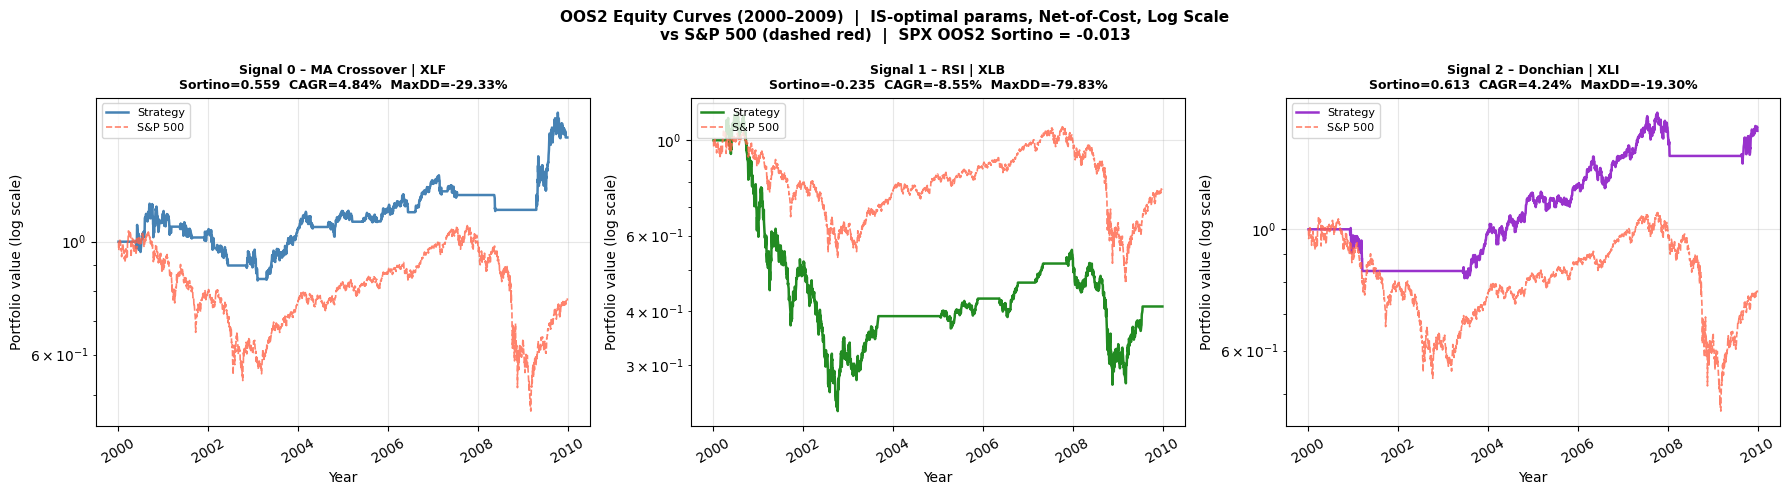

In [167]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'OOS2 Equity Curves (2000–2009)  |  IS-optimal params, Net-of-Cost, Log Scale\n'
    f'vs S&P 500 (dashed red)  |  SPX OOS2 Sortino = {spx_oos2_sortino:.3f}',
    fontsize=11, fontweight='bold')

panels_oos2 = [
    ('Signal 0 – MA Crossover | XLF', df_finance_oos2,     n_ma_oos2,  'steelblue'),
    ('Signal 1 – RSI | XLB',          df_materials_oos2,   n_rsi_oos2, 'forestgreen'),
    ('Signal 2 – Donchian | XLI',     df_industrials_oos2, n_don_oos2, 'darkorchid'),
]

for ax, (title, df_b, pv, color) in zip(axes, panels_oos2):
    idx = df_b.index
    spx_aligned = df_spx_ext.reindex(idx, method='ffill')
    spx_c = '^GSPC' if '^GSPC' in spx_aligned.columns else spx_aligned.columns[0]
    spx_pv = spx_aligned[spx_c].to_numpy(dtype=float)
    spx_pv = spx_pv / spx_pv[0]

    s, _, c, m = metrics_row(pv)
    ax.semilogy(idx, pv,     color=color,    lw=1.8, label='Strategy')
    ax.semilogy(idx, spx_pv, color='tomato', lw=1.2, linestyle='--', alpha=0.8, label='S&P 500')
    ax.set_title(f'{title}\nSortino={s:.3f}  CAGR={c:.2%}  MaxDD={m:.2%}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Portfolio value (log scale)')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 13.3 Cross-Period Robustness Summary

A signal is considered robustly viable if it maintains positive Sortino in **both** OOS periods.
The **Min OOS** column captures the worst case across OOS1 (2020–2025) and OOS2 (2000–2009) —
the single most conservative robustness metric. A signal that excels in one OOS period but
fails in the other is penalised here.


In [168]:
W = 92
print('=' * W)
print('  Cross-Period Robustness Summary — Sortino Ratio')
print('  IS-optimal params  |  gross returns  |  << = positive Sortino in BOTH OOS periods')
print('=' * W)
print(f'  {"Signal":<26} {"ETF":<5} {"IS Sort":>9} {"OOS1 Sort":>11} {"OOS2 Sort":>11} {"Min OOS":>9} {"All OOS +?":>11}')
print(f'  {"-"*84}')

all_pos_count = 0
for sig, label, etf, n_is_, n_oos1_, n_oos2_ in signals_oos2:
    s_is   = metrics_row(n_is_)[0]
    s_oos1 = metrics_row(n_oos1_)[0]
    s_oos2 = metrics_row(n_oos2_)[0]
    min_oos = min(s_oos1, s_oos2)
    all_pos = (s_oos1 > 0) and (s_oos2 > 0)
    if all_pos:
        all_pos_count += 1
    flag = '  <<' if all_pos else ''
    print(f'  {sig + " – " + label:<26} {etf:<5} {s_is:>9.3f} {s_oos1:>11.3f} {s_oos2:>11.3f} {min_oos:>9.3f} {str(all_pos):>11}{flag}')

print(f'  {"-"*84}')
spx_is_sort  = sortino_from_pv(spx_is)
spx_oos_sort = sortino_from_pv(spx_oos)
print(f'  {"S&P 500 benchmark":<26} {"SPX":<5} {spx_is_sort:>9.3f} {spx_oos_sort:>11.3f} {spx_oos2_sortino:>11.3f}'
      f' {"—":>9} {"—":>11}')
print('=' * W)
print()
print(f'  {all_pos_count} / {len(signals_oos2)} signals have positive Sortino in both OOS periods')
print('  Min OOS = min(OOS1 Sortino, OOS2 Sortino) — worst OOS period Sortino')


  Cross-Period Robustness Summary — Sortino Ratio
  IS-optimal params  |  gross returns  |  << = positive Sortino in BOTH OOS periods
  Signal                     ETF     IS Sort   OOS1 Sort   OOS2 Sort   Min OOS  All OOS +?
  ------------------------------------------------------------------------------------
  Signal 0 – MA              XLF       1.217       1.248       0.559     0.559        True  <<
  Signal 1 – RSI             XLB       1.497       1.139      -0.235    -0.235       False
  Signal 2 – Donchian        XLI       1.352       0.554       0.613     0.554        True  <<
  ------------------------------------------------------------------------------------
  S&P 500 benchmark          SPX       1.099       0.992      -0.013         —           —

  2 / 3 signals have positive Sortino in both OOS periods
  Min OOS = min(OOS1 Sortino, OOS2 Sortino) — worst OOS period Sortino


### Note on Assessment Notebook Signal Design

The research in Sections 5–10 develops and validates three signals on sector ETF baskets:

| Signal | Asset | Entry condition | Exit condition |
|--------|-------|-----------------|----------------|
| 0 — MA Crossover | XLF | $\text{MA}_{w_s}(t) > \text{MA}_{w_l}(t)$ | $\text{MA}_{w_s}(t) \le \text{MA}_{w_l}(t)$ |
| 1 — RSI | XLB | $\text{RSI}_{14}(t) < \text{oversold}$ | $\text{RSI}_{14}(t) > \text{overbought}$ |
| 2 — Donchian Channel | XLI | $P_t > \max_{i \in [t-N,t-1]} P_i$ | $P_t < \min_{i \in [t-M,t-1]} P_i$ |

The **assessment notebook** uses the same three signal types and the IS-optimal
parameters established in this research notebook, applied to the same sector ETF
baskets. The parameter transfer is direct: frozen IS-optimal parameters from
Section 5 are used without modification in the assessment notebook's signal
functions. This notebook therefore provides the complete empirical justification
for every signal design and parameter choice in the assessment submission.

**Signal distinctness:** MA Crossover detects sustained price trends via SMA
comparison (trend-following). RSI identifies mean-reverting oscillations via
the gain/loss ratio $\text{RSI} = 100 - 100/(1 + \bar{G}_p/\bar{L}_p)$
(mean reversion). Donchian Channel Breakout detects new price extremes via
rolling channel boundaries $\text{entry} = \max_{N\text{-day}} P$,
$\text{exit} = \min_{M\text{-day}} P$ (breakout / trend continuation).
The three mechanisms are conceptually independent across the trend–oscillator–
breakout taxonomy of technical signals.